In [58]:
# AudDSR Paper-Aligned Implementation
# ====================================
# Two-stage training pipeline:
# Stage 1: Discrete VQ-VAE autoencoder on all machine types (general feature space)
# Stage 2: Anomaly detector + object-specific decoder on all machine types
#
# This notebook implements the exact architecture and training flow from the AudDSR paper.

import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import torchaudio.transforms as T
from scipy.io import wavfile
from sklearn.metrics import roc_auc_score
from torch.utils.data import DataLoader, Dataset

In [59]:
# -----------------------------
# Experiment options
# TUNING FOR CROSS-MACHINE GENERALIZATION
# Current issue: slider (0.4979) and gearbox (0.5064) underperform
# Strategy: Increase capacity + adjust loss weighting
# MAIN PITFALL: Detector collapses because synthetic anomalies are too easy
# FIX: Progressively harden anomalies during Stage 2
# -----------------------------

# Quick test mode: reduce training time for fast iteration (set to False for full training)
QUIK_MODE = True  # Requested mode switch
QUICK_TEST_MODE = QUIK_MODE  # Set to False for full 5-epoch training

if QUICK_TEST_MODE:
    print("⚡ QUICK TEST MODE ENABLED (15 min training)")
    STAGE1_EPOCHS = 2
    STAGE2_EPOCHS = 2
else:
    STAGE1_EPOCHS = 5
    STAGE2_EPOCHS = 5

# (4) Quantizer capacity options.
QUANTIZER_OPTIONS = {
    "tiny":   {"q1_embeddings": 128,  "q2_embeddings": 128},
    "small":  {"q1_embeddings": 256,  "q2_embeddings": 256},
    "base":   {"q1_embeddings": 512,  "q2_embeddings": 512},
    "large":  {"q1_embeddings": 1024, "q2_embeddings": 1024},
    "xlarge": {"q1_embeddings": 2048, "q2_embeddings": 2048},
}
SELECTED_QUANTIZER = "large"  # UP from "base" to learn richer discrete features

# (6) Frontend options from the paper setup family.
FRONTEND_OPTIONS = {
    "transient": {"n_fft": 512,  "hop_length": 128, "n_mels": 128, "norm": "per_bin"},
    "balanced":  {"n_fft": 1024, "hop_length": 256, "n_mels": 128, "norm": "per_bin"},
    "harmonic":  {"n_fft": 2048, "hop_length": 512, "n_mels": 128, "norm": "global"},
    "low_compute": {"n_fft": 512, "hop_length": 256, "n_mels": 64, "norm": "none"},
}
SELECTED_FRONTEND = "balanced"

# (3.3) Anomaly mask generation processes.
# - perlin_like: smooth random map thresholding
# - band_time: random frequency band + several time segments (closest to the paper's dedicated audio mask process)
# - mixed_structured: samples a family of mask shapes to mimic varied latent faults
CORRUPTION_OPTIONS = {
    "perlin_like": {
        "mode": "perlin_like",
        "ratio": 0.18,
        "block_hw": (8, 8),
        "low_res": (8, 8),
        "replace_strategy": "random_code",
        "mix_alpha": 0.75,
        "mask_dilation": 0,
    },
    "band_time": {
        "mode": "band_time",
        "ratio": 0.28,
        "block_hw": (8, 8),
        "low_res": (8, 8),
        "replace_strategy": "batch_mix+random",
        "mix_alpha": 0.70,
        "mask_dilation": 1,
    },
    "mixed_structured": {
        "mode": "mixed_structured",
        "ratio": 0.28,
        "block_hw": (8, 8),
        "low_res": (8, 8),
        "replace_strategy": "batch_mix+random",
        "mix_alpha": 0.65,
        "mask_dilation": 2,
    },
    "point": {
        "mode": "point",
        "ratio": 0.20,
        "block_hw": (4, 4),
        "low_res": (8, 8),
        "replace_strategy": "random_code",
        "mix_alpha": 0.75,
        "mask_dilation": 0,
    },
    "time_stripe": {
        "mode": "time_stripe",
        "ratio": 0.20,
        "block_hw": (4, 16),
        "low_res": (8, 8),
        "replace_strategy": "batch_mix",
        "mix_alpha": 0.75,
        "mask_dilation": 1,
    },
    "freq_stripe": {
        "mode": "freq_stripe",
        "ratio": 0.20,
        "block_hw": (16, 4),
        "low_res": (8, 8),
        "replace_strategy": "batch_mix",
        "mix_alpha": 0.75,
        "mask_dilation": 1,
    },
    "block_medium": {
        "mode": "block",
        "ratio": 0.20,
        "block_hw": (8, 8),
        "low_res": (8, 8),
        "replace_strategy": "batch_mix",
        "mix_alpha": 0.75,
        "mask_dilation": 1,
    },
}
SELECTED_CORRUPTION = "mixed_structured"

# (5) Detector width options. Paper detector input is concat(XG, XS).
DETECTOR_OPTIONS = {
    "light": {"width": 32},
    "wide": {"width": 64},
}
SELECTED_DETECTOR = "wide"

# Paths and runtime settings
DATA_ROOT = r"C:\Users\20223669\OneDrive - TU Eindhoven\Desktop\Soroma Internship\15097779"
ALL_MACHINE_TYPES = ["bearing", "fan", "gearbox", "slider", "ToyCar", "ToyTrain", "valve"]

# Paper-mimic split strategy:
# - Stage 1 learns a general discrete latent space from all machine types.
# - Stage 2 is also trained/evaluated on ALL machine types (multi-machine anomaly detection).
STAGE1_MACHINE_TYPES = ALL_MACHINE_TYPES
STAGE2_MACHINE_TYPES = ALL_MACHINE_TYPES

TARGET_SR = 16_000
SPEC_SIZE = 128
BATCH_SIZE = 8
VISUALIZE_INDEX = 0
TOPK_RATIO = 0.05

# Score blending and calibration.
MAP_SCORE_WEIGHT = 0.00
REC_SCORE_WEIGHT = 1.00
AUDIT_REC_WEIGHT = 0.85
AUDIT_MAP_WEIGHT = 0.15
MAP_GAP_BLEND_THRESHOLD = 0.02
CALIBRATION_FILES_PER_MACHINE = 25
CALIBRATION_QUANTILE = 0.99

# Training/data budget.
# In quick mode, keep this small so the notebook can be rerun end-to-end.
if QUICK_TEST_MODE:
    SUBSET_TRAIN_PER_MACHINE = 20
    SUBSET_TEST_PER_MACHINE = 20
else:
    SUBSET_TRAIN_PER_MACHINE = 0
    SUBSET_TEST_PER_MACHINE = 100
SUBSET_SEED = 42

# Ensure this section can run independently.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Stage 1 (discrete autoencoder) paper-like defaults, increased runtime budget.
LR_STAGE1 = 2e-4
LAMBDA_X = 1.0
LAMBDA_K = 0.25

# Stage 2 settings: keep both clean/anomalous samples so detector sees both classes.
# IMPROVEMENT: Enable progressive corruption hardening to prevent detector collapse
LR_STAGE2 = 2e-4
STAGE2_ANOMALY_BATCH_RATIO = 0.5
LAMBDA_STAGE2_REC = 1.0
LAMBDA_STAGE2_DET = 5.0
FOCAL_ALPHA = 0.60
FOCAL_GAMMA = 1.0
DET_POS_WEIGHT = 4.0

# HARDENED CORRUPTION: Progressive difficulty during Stage 2 training
ENABLE_PROGRESSIVE_CORRUPTION = True  # When True, corruption difficulty increases each epoch
if ENABLE_PROGRESSIVE_CORRUPTION:
    CORRUPTION_RATIO_SCHEDULE = [0.25, 0.30, 0.35, 0.40, 0.45]  # Epoch-wise ratios
else:
    CORRUPTION_RATIO_SCHEDULE = [0.35] * STAGE2_EPOCHS  # Constant ratio

q_cfg = QUANTIZER_OPTIONS[SELECTED_QUANTIZER]
f_cfg = FRONTEND_OPTIONS[SELECTED_FRONTEND]
c_cfg = CORRUPTION_OPTIONS[SELECTED_CORRUPTION]
d_cfg = DETECTOR_OPTIONS[SELECTED_DETECTOR]

print("Selected options:")
print(f"- device:                   {device}")
print(f"- quantizer:                {SELECTED_QUANTIZER} -> {q_cfg}")
print(f"- frontend:                 {SELECTED_FRONTEND} -> {f_cfg}")
print(f"- corruption:               {SELECTED_CORRUPTION} -> {c_cfg}")
print(f"- detector:                 {SELECTED_DETECTOR} -> {d_cfg}")
print(f"- stage1 machines:          {STAGE1_MACHINE_TYPES}")
print(f"- stage2 machines:          {STAGE2_MACHINE_TYPES}")
print(f"- stage1 epochs/lr:         {STAGE1_EPOCHS} / {LR_STAGE1}")
print(f"- stage2 epochs/lr:         {STAGE2_EPOCHS} / {LR_STAGE2}")
print(f"- detector weight:          {LAMBDA_STAGE2_DET}")
print(f"- stage2 anomaly fraction:  {STAGE2_ANOMALY_BATCH_RATIO}")
print(f"- focal alpha/gamma:        {FOCAL_ALPHA} / {FOCAL_GAMMA}")
print(f"- detector pos weight:      {DET_POS_WEIGHT}")
print(f"- map/rec score weights:    {MAP_SCORE_WEIGHT} / {REC_SCORE_WEIGHT}")
print(f"- audit rec/map weights:    {AUDIT_REC_WEIGHT} / {AUDIT_MAP_WEIGHT}")
print(f"- map gap blend threshold:  {MAP_GAP_BLEND_THRESHOLD}")
print(f"- calibration files/machine: {CALIBRATION_FILES_PER_MACHINE}")
print(f"- calibration quantile:     {CALIBRATION_QUANTILE}")
print(f"- subset train per machine: {SUBSET_TRAIN_PER_MACHINE}")
print(f"- subset test per machine:  {SUBSET_TEST_PER_MACHINE}")
print(f"- progressive corruption:   {ENABLE_PROGRESSIVE_CORRUPTION}")
if ENABLE_PROGRESSIVE_CORRUPTION:
    print(f"- corruption ratio schedule: {CORRUPTION_RATIO_SCHEDULE[:STAGE2_EPOCHS]}")
print()
print("IMPROVEMENT: Stronger structured corruption, calibration thresholding, and controlled detector blending")
print("Expected: More realistic latent anomalies and clearer sample-level decisions")

⚡ QUICK TEST MODE ENABLED (15 min training)
Selected options:
- device:                   cpu
- quantizer:                large -> {'q1_embeddings': 1024, 'q2_embeddings': 1024}
- frontend:                 balanced -> {'n_fft': 1024, 'hop_length': 256, 'n_mels': 128, 'norm': 'per_bin'}
- corruption:               mixed_structured -> {'mode': 'mixed_structured', 'ratio': 0.28, 'block_hw': (8, 8), 'low_res': (8, 8), 'replace_strategy': 'batch_mix+random', 'mix_alpha': 0.65, 'mask_dilation': 2}
- detector:                 wide -> {'width': 64}
- stage1 machines:          ['bearing', 'fan', 'gearbox', 'slider', 'ToyCar', 'ToyTrain', 'valve']
- stage2 machines:          ['bearing', 'fan', 'gearbox', 'slider', 'ToyCar', 'ToyTrain', 'valve']
- stage1 epochs/lr:         2 / 0.0002
- stage2 epochs/lr:         2 / 0.0002
- detector weight:          5.0
- stage2 anomaly fraction:  0.5
- focal alpha/gamma:        0.6 / 1.0
- detector pos weight:      4.0
- map/rec score weights:    0.0 / 1.0
- aud

In [60]:
# Stage 2 strengthening overrides.
STAGE2_EPOCHS = 5
STAGE2_ANOMALY_BATCH_RATIO = 0.7
LAMBDA_STAGE2_DET = 8.0
FOCAL_ALPHA = 0.70
FOCAL_GAMMA = 1.5
DET_POS_WEIGHT = 6.0
STAGE2_MARGIN_WEIGHT = 1.0
STAGE2_MARGIN_TARGET = 0.10

if ENABLE_PROGRESSIVE_CORRUPTION:
    CORRUPTION_RATIO_SCHEDULE = [0.35, 0.45, 0.55, 0.65, 0.75]

print("[Stage2 override] Using stronger anomaly pressure and margin-based separation.")
print(
    f"[Stage2 override] anomaly ratio={STAGE2_ANOMALY_BATCH_RATIO}, "
    f"det weight={LAMBDA_STAGE2_DET}, margin={STAGE2_MARGIN_WEIGHT} @ {STAGE2_MARGIN_TARGET}"
)
print(f"[Stage2 override] focal alpha/gamma={FOCAL_ALPHA} / {FOCAL_GAMMA}, pos weight={DET_POS_WEIGHT}")
print(f"[Stage2 override] epochs={STAGE2_EPOCHS}")

[Stage2 override] Using stronger anomaly pressure and margin-based separation.
[Stage2 override] anomaly ratio=0.7, det weight=8.0, margin=1.0 @ 0.1
[Stage2 override] focal alpha/gamma=0.7 / 1.5, pos weight=6.0
[Stage2 override] epochs=5


In [61]:
def collect_wav_files(folder):
    wav_paths = []
    for root, _, files in os.walk(folder):
        for file_name in files:
            if file_name.lower().endswith(".wav"):
                wav_paths.append(os.path.join(root, file_name))
    return sorted(wav_paths)


def collect_machine_split_files(data_root, machine_type, split):
    split_dir = os.path.join(data_root, f"dev_{machine_type}", machine_type, split)
    return collect_wav_files(split_dir)


def collect_multi_machine_split_files(data_root, machine_types, split):
    files = []
    for machine in machine_types:
        files.extend(collect_machine_split_files(data_root, machine, split))
    return sorted(files)


def collect_multi_machine_split_files_limited(
    data_root,
    machine_types,
    split,
    max_per_machine=0,
    seed=0,
 ):
    if max_per_machine <= 0:
        return collect_multi_machine_split_files(data_root, machine_types, split)

    files = []
    for machine in machine_types:
        machine_files = collect_machine_split_files(data_root, machine, split)
        rng = np.random.default_rng(seed + abs(hash((machine, split))) % 1_000_000)
        if len(machine_files) > max_per_machine:
            idx = rng.choice(len(machine_files), size=max_per_machine, replace=False)
            machine_files = [machine_files[i] for i in sorted(idx.tolist())]
        files.extend(machine_files)
    return sorted(files)


def infer_machine_type_from_path(path):
    path_lower = path.replace("\\", "/").lower()
    for machine in ALL_MACHINE_TYPES:
        token = f"/dev_{machine.lower()}/"
        if token in path_lower:
            return machine
    return "unknown"


def load_waveform(path, target_sr=TARGET_SR):
    try:
        waveform, sample_rate = torchaudio.load(path)
    except (RuntimeError, ImportError, OSError):
        sample_rate, data = wavfile.read(path)
        data = np.asarray(data)
        if np.issubdtype(data.dtype, np.integer):
            data = data.astype(np.float32) / float(np.iinfo(data.dtype).max)
        else:
            data = data.astype(np.float32)
        waveform = torch.from_numpy(data).unsqueeze(0) if data.ndim == 1 else torch.from_numpy(data.T)

    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    if sample_rate != target_sr:
        waveform = torchaudio.functional.resample(waveform, sample_rate, target_sr)
    return waveform.squeeze(0)


def normalize_spec(spec, mode):
    # spec shape: (1, n_mels, time)
    if mode == "none":
        return spec
    if mode == "global":
        mean = spec.mean()
        std = spec.std().clamp_min(1e-6)
        return (spec - mean) / std
    if mode == "per_bin":
        mean = spec.mean(dim=-1, keepdim=True)
        std = spec.std(dim=-1, keepdim=True).clamp_min(1e-6)
        return (spec - mean) / std
    raise ValueError(f"Unknown normalization mode: {mode}")


def build_mel_transform(frontend_cfg):
    return T.MelSpectrogram(
        sample_rate=TARGET_SR,
        n_fft=frontend_cfg["n_fft"],
        hop_length=frontend_cfg["hop_length"],
        n_mels=frontend_cfg["n_mels"],
    )


def waveform_to_model_input(waveform, mel_transform, frontend_cfg):
    spec = torch.log1p(mel_transform(waveform)).unsqueeze(0)  # (1, n_mels, time)
    spec = normalize_spec(spec, frontend_cfg["norm"])
    spec = F.interpolate(
        spec.unsqueeze(0),
        size=(SPEC_SIZE, SPEC_SIZE),
        mode="bilinear",
        align_corners=False,
    ).squeeze(0)  # (1, H, W)
    return spec


def quantizer_usage_stats(indices, num_embeddings):
    flat = indices.reshape(-1).detach()
    counts = torch.bincount(flat, minlength=num_embeddings).float()
    total = counts.sum().clamp_min(1.0)
    probs = counts / total
    nonzero = probs > 0
    entropy = -(probs[nonzero] * torch.log(probs[nonzero])).sum() if nonzero.any() else torch.tensor(0.0, device=counts.device)
    perplexity = torch.exp(entropy)
    usage = (counts > 0).float().mean()
    return float(usage.item()), float(perplexity.item())


def build_machine_aware_permutation(file_paths, device):
    if file_paths is None:
        return None
    paths = list(file_paths)
    batch_size = len(paths)
    if batch_size <= 1:
        return torch.arange(batch_size, device=device)

    machine_to_indices = {}
    for idx, path in enumerate(paths):
        machine = infer_machine_type_from_path(path)
        machine_to_indices.setdefault(machine, []).append(idx)

    perm = torch.empty((batch_size,), device=device, dtype=torch.long)
    for idx, path in enumerate(paths):
        machine = infer_machine_type_from_path(path)
        same_machine = [candidate for candidate in machine_to_indices.get(machine, []) if candidate != idx]
        candidate_pool = same_machine if len(same_machine) > 0 else [candidate for candidate in range(batch_size) if candidate != idx]
        if len(candidate_pool) == 0:
            perm[idx] = idx
        else:
            chosen = candidate_pool[int(torch.randint(0, len(candidate_pool), (1,), device=device).item())]
            perm[idx] = chosen
    return perm


class SpectrogramFileDataset(Dataset):
    def __init__(self, file_paths, mel_transform, frontend_cfg):
        self.file_paths = file_paths
        self.mel_transform = mel_transform
        self.frontend_cfg = frontend_cfg

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        waveform = load_waveform(file_path)
        spec = waveform_to_model_input(waveform, self.mel_transform, self.frontend_cfg)
        return spec, file_path


def dilate_mask(mask, radius=1):
    if radius <= 0:
        return mask.bool()
    kernel_size = 2 * radius + 1
    return F.max_pool2d(mask.float(), kernel_size=kernel_size, stride=1, padding=radius).bool()


def make_corruption_mask(
    z_q,
    mode="band_time",
    ratio=0.2,
    block_hw=(8, 8),
    low_res=(8, 8),
    anomaly_batch_ratio=1.0,
    mask_dilation=0,
):
    bsz, _, h, w = z_q.shape
    device = z_q.device
    mask = torch.zeros((bsz, 1, h, w), device=device, dtype=torch.bool)

    if anomaly_batch_ratio <= 0:
        return mask

    n_anom = int(round(anomaly_batch_ratio * bsz))
    if anomaly_batch_ratio > 0 and n_anom == 0:
        n_anom = 1
    n_anom = max(0, min(bsz, n_anom))

    active = torch.zeros((bsz,), device=device, dtype=torch.bool)
    if n_anom > 0:
        active_idx = torch.randperm(bsz, device=device)[:n_anom]
        active[active_idx] = True

    for b in range(bsz):
        if not bool(active[b].item()):
            continue

        active_mode = mode
        if mode == "mixed_structured":
            draw = float(torch.rand(1, device=device).item())
            if draw < 0.45:
                active_mode = "band_time"
            elif draw < 0.70:
                active_mode = "block"
            elif draw < 0.85:
                active_mode = "time_stripe"
            elif draw < 0.95:
                active_mode = "freq_stripe"
            else:
                active_mode = "perlin_like"

        if active_mode == "point":
            mask[b] = torch.rand((1, h, w), device=device) < ratio
            continue

        if active_mode == "time_stripe":
            stripe_w = max(1, int(w * ratio))
            start_w = int(torch.randint(0, max(1, w - stripe_w + 1), (1,), device=device).item())
            mask[b, :, :, start_w : start_w + stripe_w] = True
            continue

        if active_mode == "freq_stripe":
            stripe_h = max(1, int(h * ratio))
            start_h = int(torch.randint(0, max(1, h - stripe_h + 1), (1,), device=device).item())
            mask[b, :, start_h : start_h + stripe_h, :] = True
            continue

        if active_mode == "block":
            block_h, block_w = block_hw
            target_area = max(1, int(ratio * h * w))
            block_area = max(1, block_h * block_w)
            num_blocks = max(1, target_area // block_area)

            for _ in range(num_blocks):
                top = int(torch.randint(0, max(1, h - block_h + 1), (1,), device=device).item())
                left = int(torch.randint(0, max(1, w - block_w + 1), (1,), device=device).item())
                mask[b, :, top : top + block_h, left : left + block_w] = True
            continue

        if active_mode == "perlin_like":
            low_h = max(2, min(h, int(low_res[0])))
            low_w = max(2, min(w, int(low_res[1])))
            coarse = torch.rand((1, 1, low_h, low_w), device=device)
            smooth = F.interpolate(coarse, size=(h, w), mode="bicubic", align_corners=False)[0, 0]
            threshold = torch.quantile(smooth.flatten(), 1.0 - ratio)
            mask[b, 0] = smooth >= threshold
            continue

        if active_mode == "band_time":
            # Audio-specific mask: contiguous frequency band plus several time chunks.
            band_h_min = max(1, int(0.10 * h))
            band_h_max = max(band_h_min, int(0.50 * h))
            band_h = int(torch.randint(band_h_min, band_h_max + 1, (1,), device=device).item())
            top = int(torch.randint(0, max(1, h - band_h + 1), (1,), device=device).item())

            seg_min = max(1, int(0.05 * w))
            seg_max = max(seg_min, int(0.25 * w))
            num_segments = int(torch.randint(2, 6, (1,), device=device).item())
            for _ in range(num_segments):
                seg_w = int(torch.randint(seg_min, seg_max + 1, (1,), device=device).item())
                left = int(torch.randint(0, max(1, w - seg_w + 1), (1,), device=device).item())
                mask[b, :, top : top + band_h, left : left + seg_w] = True
            continue

        raise ValueError(f"Unknown corruption mode: {active_mode}")

    if mask_dilation > 0:
        mask = dilate_mask(mask, radius=mask_dilation)

    return mask

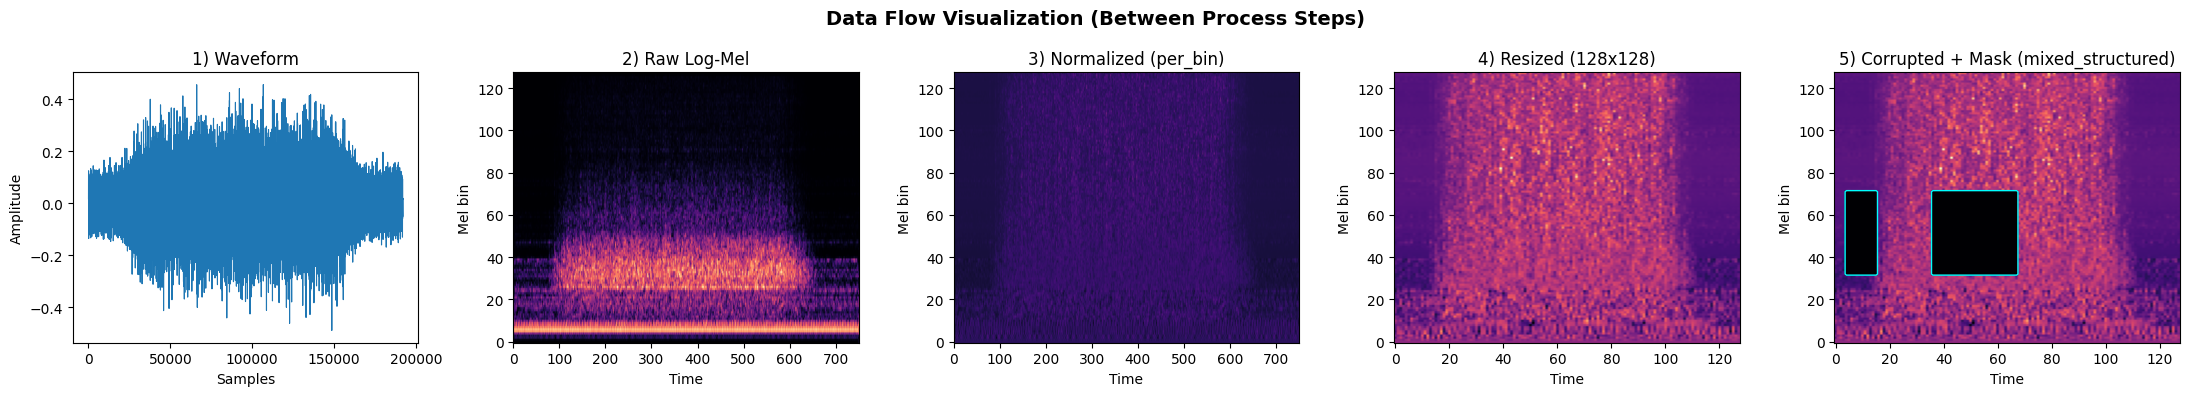

Visualized sample: C:\Users\20223669\OneDrive - TU Eindhoven\Desktop\Soroma Internship\15097779\dev_ToyCar\ToyCar\train\section_00_source_train_normal_0771_car_D2_spd_31V_mic_1.wav
QUIK_MODE: True, QUICK_TEST_MODE: True


In [62]:
# Visualize the data through intermediate processing steps.
# Run this after Cells 1-3 (imports, config, and utility functions).

viz_files = collect_multi_machine_split_files_limited(
    DATA_ROOT,
    STAGE1_MACHINE_TYPES,
    "train",
    max_per_machine=1,
    seed=SUBSET_SEED,
)

if len(viz_files) == 0:
    raise RuntimeError("No training .wav files found. Check DATA_ROOT and dataset layout.")

viz_path = viz_files[VISUALIZE_INDEX % len(viz_files)]
waveform = load_waveform(viz_path)
mel_transform_v2 = build_mel_transform(f_cfg)

# Step 1: log-mel spectrogram (before normalization)
spec_raw = torch.log1p(mel_transform_v2(waveform)).unsqueeze(0)

# Step 2: normalization
spec_norm = normalize_spec(spec_raw.clone(), f_cfg["norm"])

# Step 3: model-ready resize to SPEC_SIZE x SPEC_SIZE
spec_model = F.interpolate(
    spec_norm.unsqueeze(0),
    size=(SPEC_SIZE, SPEC_SIZE),
    mode="bilinear",
    align_corners=False,
).squeeze(0)

# Step 4: synthetic anomaly mask from current corruption config
z_dummy = F.avg_pool2d(spec_model.unsqueeze(0), kernel_size=4, stride=4)
mask_latent = make_corruption_mask(
    z_dummy,
    mode=c_cfg["mode"],
    ratio=c_cfg["ratio"],
    block_hw=c_cfg["block_hw"],
    low_res=c_cfg["low_res"],
    anomaly_batch_ratio=1.0,
)
mask_full = F.interpolate(mask_latent.float(), size=spec_model.shape[-2:], mode="nearest").squeeze().cpu().numpy()

spec_np = spec_model.squeeze().detach().cpu().numpy()
spec_corrupted = spec_np.copy()
spec_corrupted[mask_full > 0.5] = spec_np.min()

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle("Data Flow Visualization (Between Process Steps)", fontsize=14, fontweight="bold")

axes[0].plot(waveform.detach().cpu().numpy(), linewidth=0.8)
axes[0].set_title("1) Waveform")
axes[0].set_xlabel("Samples")
axes[0].set_ylabel("Amplitude")

axes[1].imshow(spec_raw.squeeze().detach().cpu().numpy(), origin="lower", aspect="auto", cmap="magma")
axes[1].set_title("2) Raw Log-Mel")

axes[2].imshow(spec_norm.squeeze().detach().cpu().numpy(), origin="lower", aspect="auto", cmap="magma")
axes[2].set_title(f"3) Normalized ({f_cfg['norm']})")

axes[3].imshow(spec_np, origin="lower", aspect="auto", cmap="magma")
axes[3].set_title(f"4) Resized ({SPEC_SIZE}x{SPEC_SIZE})")

axes[4].imshow(spec_corrupted, origin="lower", aspect="auto", cmap="magma")
axes[4].contour(mask_full, levels=[0.5], colors=["cyan"], linewidths=1.0)
axes[4].set_title(f"5) Corrupted + Mask ({c_cfg['mode']})")

for ax in axes[1:]:
    ax.set_xlabel("Time")
    ax.set_ylabel("Mel bin")

plt.tight_layout()
plt.show()

print(f"Visualized sample: {viz_path}")
print(f"QUIK_MODE: {QUIK_MODE}, QUICK_TEST_MODE: {QUICK_TEST_MODE}")

In [63]:
class FeatureEncoder(nn.Module):
    def __init__(self, in_ch=1, ch1=64, ch2=128):
        super().__init__()
        self.enc1 = nn.Sequential(
            nn.Conv2d(in_ch, ch1, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(ch1, ch2, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
        )

    def forward(self, x):
        f1 = self.enc1(x)
        f2 = self.enc2(f1)
        return f1, f2


class VectorQuantizerSimple(nn.Module):
    def __init__(self, num_embeddings, embedding_dim):
        super().__init__()
        self.embedding = nn.Embedding(num_embeddings, embedding_dim)

    def forward(self, z):
        bsz, ch, h, w = z.shape
        z_flat = z.permute(0, 2, 3, 1).contiguous().view(-1, ch)
        distances = (
            z_flat.pow(2).sum(1, keepdim=True)
            - 2 * z_flat @ self.embedding.weight.t()
            + self.embedding.weight.pow(2).sum(1)
        )
        indices = distances.argmin(dim=1)
        z_q = self.embedding(indices).view(bsz, h, w, ch).permute(0, 3, 1, 2)
        return z_q, indices


class GeneralDecoderModule1(nn.Module):
    def __init__(self, ch1=64, ch2=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(ch2, ch1, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(ch1, ch1, kernel_size=3, padding=1),
            nn.ReLU(),
        )

    def forward(self, q1):
        return self.net(q1)


class QuantizedDecoderModule2(nn.Module):
    def __init__(self, ch1=64, ch2=128):
        super().__init__()
        self.q1_proj = nn.Conv2d(ch2, ch1, kernel_size=1)
        self.to_img = nn.Sequential(
            nn.Conv2d(ch1 * 2, ch1, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(ch1, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 1, kernel_size=3, padding=1),
        )

    def forward(self, q1, q2):
        q1_up = F.interpolate(q1, size=q2.shape[-2:], mode="bilinear", align_corners=False)
        q1_up = self.q1_proj(q1_up)
        fused = torch.cat([q2, q1_up], dim=1)
        return self.to_img(fused)


class DiscreteAutoencoderPaper(nn.Module):
    def __init__(self, in_ch=1, ch1=64, ch2=128, q1_embeddings=512, q2_embeddings=512):
        super().__init__()
        self.ch1 = ch1
        self.ch2 = ch2
        self.encoder = FeatureEncoder(in_ch=in_ch, ch1=ch1, ch2=ch2)
        self.vq1 = VectorQuantizerSimple(num_embeddings=q1_embeddings, embedding_dim=ch2)
        self.general_dec1 = GeneralDecoderModule1(ch1=ch1, ch2=ch2)
        self.pre_q2_proj = nn.Conv2d(ch1 * 2, ch1, kernel_size=1)
        self.vq2 = VectorQuantizerSimple(num_embeddings=q2_embeddings, embedding_dim=ch1)
        self.general_dec2 = QuantizedDecoderModule2(ch1=ch1, ch2=ch2)

    def encode_features(self, x):
        return self.encoder(x)

    def quantize_features(self, f1, f2):
        q1, q1_idx = self.vq1(f2)
        f_u = self.general_dec1(q1)
        pre_q2 = self.pre_q2_proj(torch.cat([f1, f_u], dim=1))
        q2, q2_idx = self.vq2(pre_q2)
        return q1, q2, pre_q2, q1_idx, q2_idx

    def decode_general(self, q1, q2):
        return self.general_dec2(q1, q2)

    def forward(self, x):
        f1, f2 = self.encode_features(x)
        q1, q2, pre_q2, q1_idx, q2_idx = self.quantize_features(f1, f2)
        x_out = self.decode_general(q1, q2)
        return {
            "x_out": x_out,
            "f1": f1,
            "f2": f2,
            "pre_q2": pre_q2,
            "q1": q1,
            "q2": q2,
            "q1_idx": q1_idx,
            "q2_idx": q2_idx,
        }


class PaperAnomalyDetector(nn.Module):
    def __init__(self, width=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(2, width, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(width, width, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(width, 1, kernel_size=1),
        )

    def forward(self, x_general, x_specific):
        x = torch.cat([x_general, x_specific], dim=1)
        return torch.sigmoid(self.net(x))


def binary_focal_loss(prob, target, alpha=0.25, gamma=2.0, eps=1e-6):
    prob = prob.clamp(min=eps, max=1.0 - eps)
    ce = -(target * torch.log(prob) + (1.0 - target) * torch.log(1.0 - prob))
    pt = target * prob + (1.0 - target) * (1.0 - prob)
    alpha_t = target * alpha + (1.0 - target) * (1.0 - alpha)
    loss = alpha_t * ((1.0 - pt) ** gamma) * ce
    return loss.mean()


def weighted_bce_loss(prob, target, pos_weight=8.0, eps=1e-6):
    prob = prob.clamp(min=eps, max=1.0 - eps)
    loss = -(pos_weight * target * torch.log(prob) + (1.0 - target) * torch.log(1.0 - prob))
    return loss.mean()


class AudDSRPaperLike(nn.Module):
    def __init__(
        self,
        ch1=64,
        ch2=128,
        q1_embeddings=512,
        q2_embeddings=512,
        corruption_cfg=None,
        detector_cfg=None,
        discrete_ae=None,
    ):
        super().__init__()
        if discrete_ae is None:
            self.discrete_ae = DiscreteAutoencoderPaper(
                in_ch=1,
                ch1=ch1,
                ch2=ch2,
                q1_embeddings=q1_embeddings,
                q2_embeddings=q2_embeddings,
            )
        else:
            self.discrete_ae = discrete_ae
            ch1 = self.discrete_ae.ch1
            ch2 = self.discrete_ae.ch2

        self.object_specific_decoder = QuantizedDecoderModule2(ch1=ch1, ch2=ch2)
        self.object_specific_decoder.load_state_dict(self.discrete_ae.general_dec2.state_dict())

        detector_cfg = detector_cfg or {"width": 32}
        self.detector = PaperAnomalyDetector(width=detector_cfg["width"])
        self.corruption_cfg = corruption_cfg or {
            "mode": "band_time",
            "ratio": 0.2,
            "block_hw": (8, 8),
            "low_res": (8, 8),
            "replace_strategy": "batch_mix",
            "mix_alpha": 0.75,
            "mask_dilation": 1,
        }

    def freeze_discrete_modules(self):
        self.discrete_ae.eval()
        for p in self.discrete_ae.parameters():
            p.requires_grad = False

    def _make_batch_permutation(self, batch_size, device):
        if batch_size <= 1:
            return torch.arange(batch_size, device=device)
        shift = int(torch.randint(1, batch_size, (1,), device=device).item())
        return torch.roll(torch.arange(batch_size, device=device), shifts=shift)

    def _sample_random_codes(self, quantizer, ref_tensor):
        bsz, _, h, w = ref_tensor.shape
        idx = torch.randint(0, quantizer.embedding.num_embeddings, (bsz, h, w), device=ref_tensor.device)
        return quantizer.embedding(idx).permute(0, 3, 1, 2).contiguous()

    def _mix_latents(self, q, mask, quantizer, donor=None):
        replace_strategy = self.corruption_cfg.get("replace_strategy", "batch_mix")
        mix_alpha = float(self.corruption_cfg.get("mix_alpha", 0.75))
        if replace_strategy == "random_code":
            replacement = self._sample_random_codes(quantizer, q)
        elif replace_strategy == "batch_mix":
            if donor is None:
                donor = q[self._make_batch_permutation(q.shape[0], q.device)]
            replacement = donor
        elif replace_strategy == "batch_mix+random":
            if donor is None:
                donor = q[self._make_batch_permutation(q.shape[0], q.device)]
            replacement = mix_alpha * donor + (1.0 - mix_alpha) * self._sample_random_codes(quantizer, q)
        elif replace_strategy == "noise":
            replacement = q + 0.10 * torch.randn_like(q)
        else:
            raise ValueError(f"Unknown replace strategy: {replace_strategy}")
        return torch.where(mask.expand_as(q), replacement, q)

    def forward(self, x, file_paths=None, apply_anomaly=False, anomaly_batch_ratio=1.0):
        with torch.no_grad():
            dae_out = self.discrete_ae(x)
            q1 = dae_out["q1"]
            q2 = dae_out["q2"]
            x_general = dae_out["x_out"]

        if apply_anomaly:
            mask_q1 = make_corruption_mask(
                q1,
                mode=self.corruption_cfg["mode"],
                ratio=self.corruption_cfg["ratio"],
                block_hw=self.corruption_cfg["block_hw"],
                low_res=self.corruption_cfg.get("low_res", (8, 8)),
                anomaly_batch_ratio=anomaly_batch_ratio,
                mask_dilation=self.corruption_cfg.get("mask_dilation", 0),
            )
            mask_q2 = F.interpolate(mask_q1.float(), size=q2.shape[-2:], mode="nearest").bool()
            donor_perm = build_machine_aware_permutation(file_paths, q1.device)
            if donor_perm is None:
                donor_perm = self._make_batch_permutation(q1.shape[0], q1.device)
            donor_q1 = q1[donor_perm]
            donor_q2 = q2[donor_perm]
            q1_aug = self._mix_latents(q1, mask_q1, self.discrete_ae.vq1, donor=donor_q1)
            q2_aug = self._mix_latents(q2, mask_q2, self.discrete_ae.vq2, donor=donor_q2)
        else:
            mask_q1 = torch.zeros((q1.shape[0], 1, q1.shape[2], q1.shape[3]), device=q1.device, dtype=torch.bool)
            mask_q2 = F.interpolate(mask_q1.float(), size=q2.shape[-2:], mode="nearest").bool()
            q1_aug = q1
            q2_aug = q2

        x_specific = self.object_specific_decoder(q1_aug, q2_aug)
        anomaly_map = self.detector(x_general, x_specific)
        return {
            "x_general": x_general,
            "x_specific": x_specific,
            "x_out": x_general,
            "x_clean": x_specific,
            "anomaly_map": anomaly_map,
            "mask": mask_q1,
            "mask_q2": mask_q2,
            "q1": q1,
            "q2": q2,
            "q1_idx": dae_out.get("q1_idx"),
            "q2_idx": dae_out.get("q2_idx"),
            "q1_aug": q1_aug,
            "q2_aug": q2_aug,
        }


def stage1_vqvae_loss(x, outputs, lambda_x=1.0, lambda_k=0.25):
    rec = F.mse_loss(outputs["x_out"], x)
    q1_codebook = F.mse_loss(outputs["f2"].detach(), outputs["q1"])
    q1_commit = F.mse_loss(outputs["f2"], outputs["q1"].detach())
    q2_codebook = F.mse_loss(outputs["pre_q2"].detach(), outputs["q2"])
    q2_commit = F.mse_loss(outputs["pre_q2"], outputs["q2"].detach())
    total = lambda_x * rec + q1_codebook + lambda_k * q1_commit + q2_codebook + lambda_k * q2_commit
    return total, {
        "total": float(total.item()),
        "rec": float(rec.item()),
        "q1_cb": float(q1_codebook.item()),
        "q1_cm": float(q1_commit.item()),
        "q2_cb": float(q2_codebook.item()),
        "q2_cm": float(q2_commit.item()),
    }


def stage2_auddsr_loss(
    x,
    outputs,
    lambda_rec=1.0,
    lambda_det=1.0,
    alpha=0.25,
    gamma=2.0,
    pos_weight=8.0,
    focal_mix=0.5,
 ):
    rec_specific = F.mse_loss(outputs["x_specific"], x)
    det_target = F.interpolate(outputs["mask"].float(), size=x.shape[-2:], mode="nearest")
    det_focal = binary_focal_loss(outputs["anomaly_map"], det_target, alpha=alpha, gamma=gamma)
    det_bce = weighted_bce_loss(outputs["anomaly_map"], det_target, pos_weight=pos_weight)
    det_loss = focal_mix * det_focal + (1.0 - focal_mix) * det_bce
    total = lambda_rec * rec_specific + lambda_det * det_loss
    return total, {
        "total": float(total.item()),
        "rec_specific": float(rec_specific.item()),
        "det": float(det_loss.item()),
        "det_focal": float(det_focal.item()),
        "det_bce": float(det_bce.item()),
    }

In [64]:
def stage2_auddsr_loss(
    x,
    outputs,
    lambda_rec=1.0,
    lambda_det=1.0,
    alpha=0.25,
    gamma=2.0,
    pos_weight=8.0,
    focal_mix=0.5,
    margin_weight=1.0,
    margin_target=0.10,
):
    rec_specific = F.mse_loss(outputs["x_specific"], x)
    det_target = F.interpolate(outputs["mask"].float(), size=x.shape[-2:], mode="nearest")
    det_focal = binary_focal_loss(outputs["anomaly_map"], det_target, alpha=alpha, gamma=gamma)
    det_bce = weighted_bce_loss(outputs["anomaly_map"], det_target, pos_weight=pos_weight)
    det_loss = focal_mix * det_focal + (1.0 - focal_mix) * det_bce

    det_margin = torch.zeros((), device=x.device, dtype=det_loss.dtype)
    flat_map = outputs["anomaly_map"].view(outputs["anomaly_map"].shape[0], -1)
    flat_target = det_target.view(det_target.shape[0], -1) > 0.5
    margin_terms = []
    for sample_map, sample_target in zip(flat_map, flat_target):
        if sample_target.any() and (~sample_target).any():
            pos_mean = sample_map[sample_target].mean()
            neg_mean = sample_map[~sample_target].mean()
            margin_terms.append(F.relu(margin_target - (pos_mean - neg_mean)))
    if margin_terms:
        det_margin = torch.stack(margin_terms).mean()

    total = lambda_rec * rec_specific + lambda_det * det_loss + margin_weight * det_margin
    return total, {
        "total": float(total.item()),
        "rec_specific": float(rec_specific.item()),
        "det": float(det_loss.item()),
        "det_focal": float(det_focal.item()),
        "det_bce": float(det_bce.item()),
        "det_margin": float(det_margin.item()),
    }

In [73]:
# Stage 1 bottleneck fix: soft quantization plus a usage regularizer.
STAGE1_EPOCHS = 5
SUBSET_TRAIN_PER_MACHINE = 0
SUBSET_TEST_PER_MACHINE = 0
VQ_TEMPERATURE = 1.8
STAGE1_CODEBOOK_USAGE_WEIGHT = 0.20
STAGE1_USAGE_EPS = 1e-6


def codebook_usage_penalty(probs):
    probs_flat = probs.reshape(-1, probs.shape[-1])
    usage = probs_flat.mean(dim=0)
    usage = usage / usage.sum().clamp_min(STAGE1_USAGE_EPS)
    return (usage * usage.clamp_min(STAGE1_USAGE_EPS).log()).sum()


class VectorQuantizerSimple(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, temperature=VQ_TEMPERATURE):
        super().__init__()
        self.embedding = nn.Embedding(num_embeddings, embedding_dim)
        self.temperature = temperature

    def forward(self, z):
        bsz, ch, h, w = z.shape
        z_flat = z.permute(0, 2, 3, 1).contiguous().view(-1, ch)
        distances = (
            z_flat.pow(2).sum(1, keepdim=True)
            - 2 * z_flat @ self.embedding.weight.t()
            + self.embedding.weight.pow(2).sum(1)
        )
        probs = F.softmax(-distances / self.temperature, dim=1)
        indices = probs.argmax(dim=1)
        z_soft = probs @ self.embedding.weight
        z_hard = self.embedding(indices)
        z_q = z_soft + (z_hard - z_soft).detach()
        z_q = z_q.view(bsz, h, w, ch).permute(0, 3, 1, 2)
        return z_q, indices, probs


class DiscreteAutoencoderPaper(nn.Module):
    def __init__(self, in_ch=1, ch1=64, ch2=128, q1_embeddings=512, q2_embeddings=512):
        super().__init__()
        self.ch1 = ch1
        self.ch2 = ch2
        self.encoder = FeatureEncoder(in_ch=in_ch, ch1=ch1, ch2=ch2)
        self.vq1 = VectorQuantizerSimple(num_embeddings=q1_embeddings, embedding_dim=ch2)
        self.general_dec1 = GeneralDecoderModule1(ch1=ch1, ch2=ch2)
        self.pre_q2_proj = nn.Conv2d(ch1 * 2, ch1, kernel_size=1)
        self.vq2 = VectorQuantizerSimple(num_embeddings=q2_embeddings, embedding_dim=ch1)
        self.general_dec2 = QuantizedDecoderModule2(ch1=ch1, ch2=ch2)

    def encode_features(self, x):
        return self.encoder(x)

    def quantize_features(self, f1, f2):
        q1, q1_idx, q1_probs = self.vq1(f2)
        f_u = self.general_dec1(q1)
        pre_q2 = self.pre_q2_proj(torch.cat([f1, f_u], dim=1))
        q2, q2_idx, q2_probs = self.vq2(pre_q2)
        return q1, q2, pre_q2, q1_idx, q2_idx, q1_probs, q2_probs

    def decode_general(self, q1, q2):
        return self.general_dec2(q1, q2)

    def forward(self, x):
        f1, f2 = self.encode_features(x)
        q1, q2, pre_q2, q1_idx, q2_idx, q1_probs, q2_probs = self.quantize_features(f1, f2)
        x_out = self.decode_general(q1, q2)
        return {
            "x_out": x_out,
            "f1": f1,
            "f2": f2,
            "pre_q2": pre_q2,
            "q1": q1,
            "q2": q2,
            "q1_idx": q1_idx,
            "q2_idx": q2_idx,
            "q1_probs": q1_probs,
            "q2_probs": q2_probs,
        }


def stage1_vqvae_loss(x, outputs, lambda_x=1.0, lambda_k=0.25):
    rec = F.mse_loss(outputs["x_out"], x)
    q1_codebook = F.mse_loss(outputs["f2"].detach(), outputs["q1"])
    q1_commit = F.mse_loss(outputs["f2"], outputs["q1"].detach())
    q2_codebook = F.mse_loss(outputs["pre_q2"].detach(), outputs["q2"])
    q2_commit = F.mse_loss(outputs["pre_q2"], outputs["q2"].detach())
    q1_usage = codebook_usage_penalty(outputs["q1_probs"])
    q2_usage = codebook_usage_penalty(outputs["q2_probs"])

    total = (
        lambda_x * rec
        + q1_codebook
        + lambda_k * q1_commit
        + q2_codebook
        + lambda_k * q2_commit
        + STAGE1_CODEBOOK_USAGE_WEIGHT * (q1_usage + q2_usage)
    )

    return total, {
        "total": float(total.item()),
        "rec": float(rec.item()),
        "q1_cb": float(q1_codebook.item()),
        "q1_cm": float(q1_commit.item()),
        "q2_cb": float(q2_codebook.item()),
        "q2_cm": float(q2_commit.item()),
        "q1_usage": float(q1_usage.item()),
        "q2_usage": float(q2_usage.item()),
    }

print("[Stage1 override] Enabled soft quantization and usage regularization.")
print(f"[Stage1 override] temperature={VQ_TEMPERATURE}, usage_weight={STAGE1_CODEBOOK_USAGE_WEIGHT}, epochs={STAGE1_EPOCHS}")
print(f"[Stage1 override] using full training split per machine")

[Stage1 override] Enabled soft quantization and usage regularization.
[Stage1 override] temperature=1.8, usage_weight=0.2, epochs=5
[Stage1 override] using full training split per machine


In [66]:
# ============================================================================
# Full Two-Stage Training: Stage 1 (Discrete VQ-VAE) + Stage 2 (AudDSR)
# ============================================================================

# Build mel transform from frontend config
mel_transform_v2 = build_mel_transform(f_cfg)

# --- Data Load & Preparation ---
print("[Training] Collecting wav files for Stage 1 and Stage 2...")

# Build Stage 1 dataset (all machine types, training split)
stage1_files = collect_multi_machine_split_files_limited(
    DATA_ROOT,
    STAGE1_MACHINE_TYPES,
    "train",
    max_per_machine=SUBSET_TRAIN_PER_MACHINE if SUBSET_TRAIN_PER_MACHINE > 0 else 0,
    seed=SUBSET_SEED
)

stage1_dataset = SpectrogramFileDataset(stage1_files, mel_transform_v2, f_cfg)
train_loader_s1 = DataLoader(stage1_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
print(f"[Training] Stage 1: {len(stage1_files)} files, {len(train_loader_s1)} batches")

# Build Stage 2 dataset (all machine types, training split)
stage2_files = collect_multi_machine_split_files_limited(
    DATA_ROOT,
    STAGE2_MACHINE_TYPES,
    "train",
    max_per_machine=SUBSET_TRAIN_PER_MACHINE if SUBSET_TRAIN_PER_MACHINE > 0 else 0,
    seed=SUBSET_SEED
)

stage2_dataset = SpectrogramFileDataset(stage2_files, mel_transform_v2, f_cfg)
train_loader_v2 = DataLoader(stage2_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
monitor_batch_size = max(1, min(BATCH_SIZE, len(stage2_dataset)))
monitor_loader_v2 = DataLoader(stage2_dataset, batch_size=monitor_batch_size, shuffle=False, num_workers=0)
monitor_batch_v2 = next(iter(monitor_loader_v2))
monitor_x_v2 = monitor_batch_v2[0].to(device)
monitor_paths_v2 = monitor_batch_v2[1]
print(f"[Training] Stage 2: {len(stage2_files)} files, {len(train_loader_v2)} batches")

# --- Stage 1: Discrete VQ-VAE Training ---
print("\n" + "="*70)
print("STAGE 1: Discrete VQ-VAE Training")
print("="*70)

discrete_ae = DiscreteAutoencoderPaper(
    in_ch=1,
    ch1=f_cfg.get("ch1", 64),
    ch2=f_cfg.get("ch2", 128),
    q1_embeddings=q_cfg.get("q1_embeddings", 1024),
    q2_embeddings=q_cfg.get("q2_embeddings", 1024),
).to(device)

optimizer_stage1 = torch.optim.Adam(discrete_ae.parameters(), lr=LR_STAGE1)
stage1_loss_history = {
    "total": [],
    "rec": [],
    "q1_cb": [],
    "q1_cm": [],
    "q2_cb": [],
    "q2_cm": [],
}

discrete_ae.train()
for epoch in range(1, STAGE1_EPOCHS + 1):
    running = {
        "total": 0.0,
        "rec": 0.0,
        "q1_cb": 0.0,
        "q1_cm": 0.0,
        "q2_cb": 0.0,
        "q2_cm": 0.0,
    }

    for batch in train_loader_s1:
        x, _ = batch
        x = x.to(device)

        optimizer_stage1.zero_grad()
        outputs = discrete_ae(x)
        loss, parts = stage1_vqvae_loss(x, outputs, lambda_x=LAMBDA_X, lambda_k=LAMBDA_K)
        loss.backward()
        optimizer_stage1.step()

        for key in running:
            running[key] += parts[key]

    n_batches = max(1, len(train_loader_s1))

    # Record epoch-level losses
    for key in stage1_loss_history:
        stage1_loss_history[key].append(running[key] / n_batches)

    print(
        f"[Stage1] Epoch {epoch}/{STAGE1_EPOCHS} | "
        f"total={running['total']/n_batches:.4f} | "
        f"rec={running['rec']/n_batches:.4f} | "
        f"q1_cb={running['q1_cb']/n_batches:.4f} | "
        f"q1_cm={running['q1_cm']/n_batches:.4f} | "
        f"q2_cb={running['q2_cb']/n_batches:.4f} | "
        f"q2_cm={running['q2_cm']/n_batches:.4f}"
    )

print("\n[Stage1] Training complete.")

# --- Stage 2: Object-Specific Decoder + Anomaly Detector ---
print("\n" + "="*70)
print("STAGE 2: Object-Specific Decoder + Anomaly Detector Training")
print("="*70)

# Create Stage 2 model with trained discrete AE
paper_model = AudDSRPaperLike(
    ch1=f_cfg.get("ch1", 64),
    ch2=f_cfg.get("ch2", 128),
    q1_embeddings=q_cfg.get("q1_embeddings", 1024),
    q2_embeddings=q_cfg.get("q2_embeddings", 1024),
    corruption_cfg=c_cfg,
    detector_cfg=d_cfg,
    discrete_ae=discrete_ae,  # Use trained Stage 1 model
).to(device)

paper_model.freeze_discrete_modules()

# Optimizer only for trainable parts (decoder + detector)
trainable_params = list(paper_model.object_specific_decoder.parameters()) + list(paper_model.detector.parameters())
optimizer_stage2 = torch.optim.Adam(trainable_params, lr=LR_STAGE2)

stage2_loss_history = {
    "total": [],
    "rec_specific": [],
    "det": [],
    "det_focal": [],
    "det_bce": [],
}
stage2_diagnostics_history = {
    "mask_frac": [],
    "map_mask_mean": [],
    "map_bg_mean": [],
    "map_gap": [],
    "clean_map_mean": [],
    "clean_rec_mse": [],
    "anom_rec_mse": [],
}

paper_model.train()
for epoch in range(1, STAGE2_EPOCHS + 1):
    running = {
        "total": 0.0,
        "rec_specific": 0.0,
        "det": 0.0,
        "det_focal": 0.0,
        "det_bce": 0.0,
    }

    # IMPROVEMENT: Get epoch-specific corruption ratio for progressive hardening
    if ENABLE_PROGRESSIVE_CORRUPTION:
        epoch_corruption_ratio = CORRUPTION_RATIO_SCHEDULE[min(epoch - 1, len(CORRUPTION_RATIO_SCHEDULE) - 1)]
        original_ratio = c_cfg["ratio"]
        c_cfg["ratio"] = epoch_corruption_ratio
    else:
        epoch_corruption_ratio = c_cfg["ratio"]

    for batch in train_loader_v2:
        x, paths = batch
        x = x.to(device)

        optimizer_stage2.zero_grad()
        outputs = paper_model(
            x,
            file_paths=paths,
            apply_anomaly=True,
            anomaly_batch_ratio=STAGE2_ANOMALY_BATCH_RATIO,
        )
        loss, parts = stage2_auddsr_loss(
            x,
            outputs,
            lambda_rec=LAMBDA_STAGE2_REC,
            lambda_det=LAMBDA_STAGE2_DET,
            alpha=FOCAL_ALPHA,
            gamma=FOCAL_GAMMA,
            pos_weight=DET_POS_WEIGHT,
            focal_mix=0.5,
        )
        loss.backward()
        optimizer_stage2.step()

        for key in running:
            running[key] += parts[key]

    n_batches = max(1, len(train_loader_v2))

    # Record epoch-level losses
    for key in stage2_loss_history:
        stage2_loss_history[key].append(running[key] / n_batches)

    paper_model.eval()
    with torch.no_grad():
        clean_monitor = paper_model(monitor_x_v2, file_paths=monitor_paths_v2, apply_anomaly=False)
        anom_monitor = paper_model(monitor_x_v2, file_paths=monitor_paths_v2, apply_anomaly=True, anomaly_batch_ratio=1.0)
        clean_map = clean_monitor["anomaly_map"]
        anom_map = anom_monitor["anomaly_map"]
        target_map = F.interpolate(anom_monitor["mask"].float(), size=anom_map.shape[-2:], mode="nearest")
        active_mask = target_map > 0.5
        inactive_mask = ~active_mask
        mask_frac = float(target_map.mean().item())
        map_mask_mean = float(anom_map[active_mask].mean().item()) if active_mask.any() else float(anom_map.mean().item())
        map_bg_mean = float(anom_map[inactive_mask].mean().item()) if inactive_mask.any() else map_mask_mean
        map_gap = map_mask_mean - map_bg_mean
        clean_map_mean = float(clean_map.mean().item())
        clean_rec_mse = float(F.mse_loss(clean_monitor["x_specific"], monitor_x_v2).item())
        anom_rec_mse = float(F.mse_loss(anom_monitor["x_specific"], monitor_x_v2).item())

    stage2_diagnostics_history["mask_frac"].append(mask_frac)
    stage2_diagnostics_history["map_mask_mean"].append(map_mask_mean)
    stage2_diagnostics_history["map_bg_mean"].append(map_bg_mean)
    stage2_diagnostics_history["map_gap"].append(map_gap)
    stage2_diagnostics_history["clean_map_mean"].append(clean_map_mean)
    stage2_diagnostics_history["clean_rec_mse"].append(clean_rec_mse)
    stage2_diagnostics_history["anom_rec_mse"].append(anom_rec_mse)

    print(
        f"[Stage2] Epoch {epoch}/{STAGE2_EPOCHS} (corr_ratio={epoch_corruption_ratio:.2f}) | "
        f"total={running['total']/n_batches:.4f} | "
        f"rec_specific={running['rec_specific']/n_batches:.4f} | "
        f"det={running['det']/n_batches:.4f} | "
        f"focal={running['det_focal']/n_batches:.4f} | "
        f"wbce={running['det_bce']/n_batches:.4f}"
    )
    print(
        f"[Stage2][Diag] mask_frac={mask_frac:.3f} | map_mask={map_mask_mean:.4f} | "
        f"map_bg={map_bg_mean:.4f} | gap={map_gap:.4f} | clean_map={clean_map_mean:.4f} | "
        f"clean_rec={clean_rec_mse:.4f} | anom_rec={anom_rec_mse:.4f}"
    )
    if map_gap < 0.02:
        print("[Stage2][Warn] Detector separation is weak; try stronger corruption or a wider detector.")
    if anom_rec_mse <= clean_rec_mse:
        print("[Stage2][Warn] Synthetic corruption is not increasing reconstruction error enough.")

    if ENABLE_PROGRESSIVE_CORRUPTION:
        c_cfg["ratio"] = original_ratio
    paper_model.train()

print("\nTwo-stage paper-like training pass complete.")

[Training] Collecting wav files for Stage 1 and Stage 2...
[Training] Stage 1: 7000 files, 875 batches
[Training] Stage 2: 7000 files, 875 batches

STAGE 1: Discrete VQ-VAE Training
[Stage1] Epoch 1/5 | total=0.9924 | rec=0.2610 | q1_cb=0.7329 | q1_cm=0.7329 | q2_cb=0.7084 | q2_cm=0.7084
[Stage1] Epoch 2/5 | total=0.7237 | rec=0.1415 | q1_cb=0.7278 | q1_cm=0.7278 | q2_cb=0.7048 | q2_cm=0.7048
[Stage1] Epoch 3/5 | total=0.6701 | rec=0.1140 | q1_cb=0.7231 | q1_cm=0.7231 | q2_cb=0.6996 | q2_cm=0.6996
[Stage1] Epoch 4/5 | total=0.6449 | rec=0.0962 | q1_cb=0.7215 | q1_cm=0.7215 | q2_cb=0.7011 | q2_cm=0.7011
[Stage1] Epoch 5/5 | total=0.6316 | rec=0.0850 | q1_cb=0.7210 | q1_cm=0.7210 | q2_cb=0.7044 | q2_cm=0.7044

[Stage1] Training complete.

STAGE 2: Object-Specific Decoder + Anomaly Detector Training
[Stage2] Epoch 1/5 (corr_ratio=0.35) | total=1.6424 | rec_specific=0.5680 | det=0.1336 | focal=0.0202 | wbce=0.2470
[Stage2][Diag] mask_frac=0.390 | map_mask=0.9855 | map_bg=0.0239 | gap=0.961

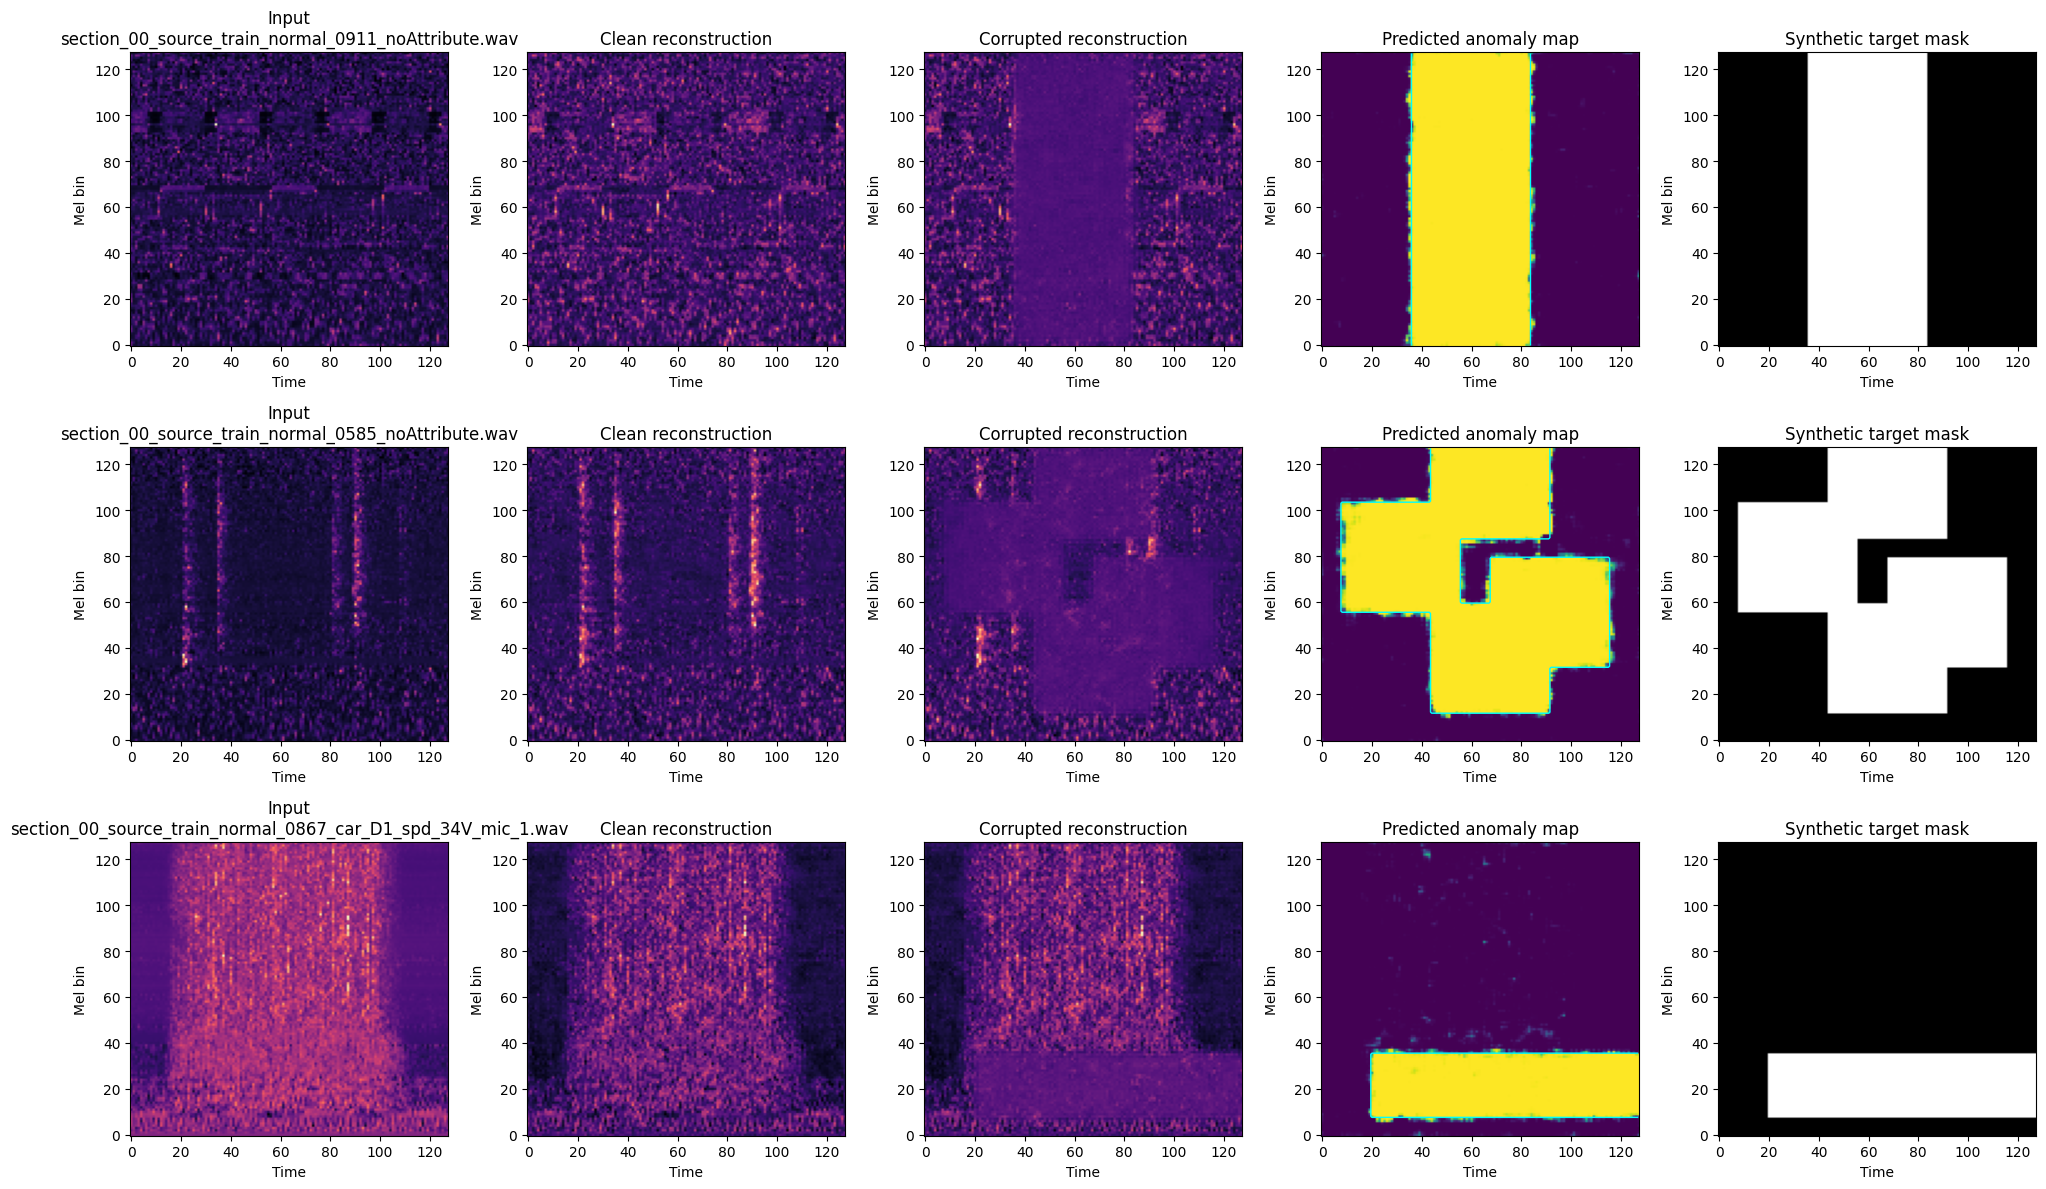

Diagnostic batch: 3 files
Predicted map mean on mask: 0.9944
Predicted map mean on background: 0.0173
Gap: 0.9772


AudDSRPaperLike(
  (discrete_ae): DiscreteAutoencoderPaper(
    (encoder): FeatureEncoder(
      (enc1): Sequential(
        (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (1): ReLU()
      )
      (enc2): Sequential(
        (0): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (1): ReLU()
      )
    )
    (vq1): VectorQuantizerSimple(
      (embedding): Embedding(1024, 128)
    )
    (general_dec1): GeneralDecoderModule1(
      (net): Sequential(
        (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (1): ReLU()
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU()
      )
    )
    (pre_q2_proj): Conv2d(128, 64, kernel_size=(1, 1), stride=(1, 1))
    (vq2): VectorQuantizerSimple(
      (embedding): Embedding(1024, 64)
    )
    (general_dec2): QuantizedDecoderModule2(
      (q1_proj): Conv2d(128, 64, kernel_size=(1, 1), stride=(1, 1))
     

In [67]:
# Diagnostic view: synthetic anomaly simulation and detector response.
if "paper_model" not in globals():
    raise RuntimeError("Run the training cell first so paper_model exists.")

diagnostic_batch_size = max(1, min(3, len(stage2_dataset)))
diagnostic_loader = DataLoader(stage2_dataset, batch_size=diagnostic_batch_size, shuffle=True, num_workers=0)
diag_batch = next(iter(diagnostic_loader))
diag_x = diag_batch[0].to(device)
diag_paths = diag_batch[1]

paper_model.eval()
with torch.no_grad():
    clean_diag = paper_model(diag_x, apply_anomaly=False)
    anom_diag = paper_model(diag_x, apply_anomaly=True, anomaly_batch_ratio=1.0)
    diag_mask = F.interpolate(anom_diag["mask"].float(), size=anom_diag["anomaly_map"].shape[-2:], mode="nearest")
    diag_map = anom_diag["anomaly_map"]

fig, axes = plt.subplots(diag_x.shape[0], 5, figsize=(20, 4 * diag_x.shape[0]))
axes = np.atleast_2d(axes)

for row in range(diag_x.shape[0]):
    axes[row, 0].imshow(diag_x[row, 0].detach().cpu().numpy(), origin="lower", aspect="auto", cmap="magma")
    axes[row, 0].set_title(f"Input\n{os.path.basename(diag_paths[row])}")

    axes[row, 1].imshow(clean_diag["x_specific"][row, 0].detach().cpu().numpy(), origin="lower", aspect="auto", cmap="magma")
    axes[row, 1].set_title("Clean reconstruction")

    axes[row, 2].imshow(anom_diag["x_specific"][row, 0].detach().cpu().numpy(), origin="lower", aspect="auto", cmap="magma")
    axes[row, 2].set_title("Corrupted reconstruction")

    axes[row, 3].imshow(diag_map[row, 0].detach().cpu().numpy(), origin="lower", aspect="auto", cmap="viridis")
    axes[row, 3].contour(diag_mask[row, 0].detach().cpu().numpy(), levels=[0.5], colors=["cyan"], linewidths=1.0)
    axes[row, 3].set_title("Predicted anomaly map")

    axes[row, 4].imshow(diag_mask[row, 0].detach().cpu().numpy(), origin="lower", aspect="auto", cmap="gray")
    axes[row, 4].set_title("Synthetic target mask")

    for col in range(5):
        axes[row, col].set_xlabel("Time")
        axes[row, col].set_ylabel("Mel bin")

plt.tight_layout()
plt.show()

diag_map_mask_mean = float(diag_map[diag_mask > 0.5].mean().item()) if (diag_mask > 0.5).any() else float(diag_map.mean().item())
diag_map_bg_mean = float(diag_map[diag_mask <= 0.5].mean().item()) if (diag_mask <= 0.5).any() else diag_map_mask_mean
print(f"Diagnostic batch: {len(diag_paths)} files")
print(f"Predicted map mean on mask: {diag_map_mask_mean:.4f}")
print(f"Predicted map mean on background: {diag_map_bg_mean:.4f}")
print(f"Gap: {diag_map_mask_mean - diag_map_bg_mean:.4f}")
paper_model.train()

In [68]:
# Full-dataset unsupervised kNN scoring (self-contained).
if "paper_model" not in globals():
    raise RuntimeError("Run Cell 5 first so paper_model exists.")


def infer_label_from_filename(path):
    name = os.path.basename(path).lower()
    if "anomaly" in name:
        return 1
    if "normal" in name:
        return 0
    return None


def compute_auc_metrics(file_paths, scores, tag):
    labels = np.asarray([infer_label_from_filename(p) for p in file_paths], dtype=object)
    valid = np.asarray([lbl is not None for lbl in labels])
    print(f"[{tag}] files scored: {len(file_paths)}")
    print(f"[{tag}] files with inferred labels: {valid.sum()}")

    if valid.sum() == 0:
        print(f"[{tag}] AUROC/pAUC unavailable: no inferred labels.")
        return None, None

    y_true = labels[valid].astype(int)
    y_score = scores[valid].astype(np.float32)
    if len(np.unique(y_true)) < 2:
        print(f"[{tag}] AUROC/pAUC unavailable: labels do not contain both classes.")
        return None, None

    auroc = roc_auc_score(y_true, y_score)
    pauc_01 = roc_auc_score(y_true, y_score, max_fpr=0.1)
    print(f"[{tag}] AUROC: {auroc:.4f}")
    print(f"[{tag}] pAUC@0.1: {pauc_01:.4f}")
    return auroc, pauc_01


def anomaly_map_to_file_score(anomaly_map, topk_ratio=0.05):
    flat = anomaly_map.flatten(1)
    k = max(1, int(flat.shape[1] * topk_ratio))
    topk_vals = torch.topk(flat, k=k, dim=1).values
    return topk_vals.mean(dim=1)


def rec_feature_vector(model_obj, file_path, topk_ratio=0.05):
    waveform = load_waveform(file_path)
    x = waveform_to_model_input(waveform, mel_transform_v2, f_cfg).unsqueeze(0).to(device)
    with torch.no_grad():
        out = model_obj(x, apply_anomaly=False)
    rec_err = torch.abs(x - out["x_specific"]).flatten().detach().cpu().numpy().astype(np.float32)

    q90 = float(np.quantile(rec_err, 0.90))
    q95 = float(np.quantile(rec_err, 0.95))
    q99 = float(np.quantile(rec_err, 0.99))
    topk = max(1, int(rec_err.size * topk_ratio))
    topk_mean = float(np.mean(np.partition(rec_err, -topk)[-topk:]))

    return np.asarray(
        [float(np.mean(rec_err)), float(np.std(rec_err)), q90, q95, q99, topk_mean],
        dtype=np.float32,
    )


def build_feature_bank(model_obj, file_list, desc):
    feats = []
    machines = []
    for i, path in enumerate(file_list, start=1):
        feats.append(rec_feature_vector(model_obj, path, topk_ratio=TOPK_RATIO))
        machines.append(infer_machine_type_from_path(path))
        if i % 200 == 0 or i == len(file_list):
            print(f"[{desc}] processed {i}/{len(file_list)} files")
    return np.vstack(feats), machines


def knn_distance_score(test_feat, train_feats, k=7):
    if train_feats.shape[0] == 0:
        return float("nan")
    d = np.sqrt(np.sum((train_feats - test_feat[None, :]) ** 2, axis=1))
    k_eff = min(k, d.shape[0])
    return float(np.mean(np.partition(d, k_eff - 1)[:k_eff]))


train_files_full = collect_multi_machine_split_files(
    DATA_ROOT,
    STAGE2_MACHINE_TYPES,
    split="train",
 )
test_files_full = collect_multi_machine_split_files(
    DATA_ROOT,
    STAGE2_MACHINE_TYPES,
    split="test",
 )

print(f"Full train files: {len(train_files_full)}")
print(f"Full test files:  {len(test_files_full)}")

print("Building FULL unsupervised train feature bank...")
train_feats_full, train_machines_full = build_feature_bank(
    paper_model,
    train_files_full,
    desc="TrainFeatFull",
 )
print("Building FULL unsupervised test feature bank...")
test_feats_full, test_machines_full = build_feature_bank(
    paper_model,
    test_files_full,
    desc="TestFeatFull",
 )

feat_mu_full = train_feats_full.mean(axis=0, keepdims=True)
feat_sigma_full = train_feats_full.std(axis=0, keepdims=True) + 1e-6
train_z_full = (train_feats_full - feat_mu_full) / feat_sigma_full
test_z_full = (test_feats_full - feat_mu_full) / feat_sigma_full

train_by_machine_full = {}
for machine in STAGE2_MACHINE_TYPES:
    idx = [i for i, mm in enumerate(train_machines_full) if mm == machine]
    train_by_machine_full[machine] = (
        train_z_full[idx] if len(idx) > 0 else np.zeros((0, train_z_full.shape[1]), dtype=np.float32)
    )

unsup_scores_full = []
for i, machine in enumerate(test_machines_full):
    local_bank = train_by_machine_full.get(machine, None)
    if local_bank is None or local_bank.shape[0] == 0:
        local_bank = train_z_full
    unsup_scores_full.append(knn_distance_score(test_z_full[i], local_bank, k=7))
unsup_scores_full = np.asarray(unsup_scores_full, dtype=np.float32)

print(
    f"[Unsupervised-kNN-Full] score stats: min={unsup_scores_full.min():.4f}, "
    f"mean={unsup_scores_full.mean():.4f}, max={unsup_scores_full.max():.4f}, std={unsup_scores_full.std():.4f}"
 )
compute_auc_metrics(test_files_full, unsup_scores_full, tag="Test:Unsupervised-kNN-Full")

print("Per-machine AUROC (Unsupervised-kNN-Full):")
for machine in STAGE2_MACHINE_TYPES:
    idx = [i for i, mm in enumerate(test_machines_full) if mm == machine]
    if len(idx) == 0:
        continue
    machine_files = [test_files_full[i] for i in idx]
    machine_scores = unsup_scores_full[idx]
    auroc_m, pauc_m = compute_auc_metrics(
        machine_files,
        machine_scores,
        tag=f"Test:Unsup-kNN-Full-{machine}",
    )
    if auroc_m is not None:
        print(f"  {machine}: AUROC={auroc_m:.4f}, pAUC@0.1={pauc_m:.4f}")

Full train files: 7000
Full test files:  1400
Building FULL unsupervised train feature bank...
[TrainFeatFull] processed 200/7000 files
[TrainFeatFull] processed 400/7000 files
[TrainFeatFull] processed 600/7000 files
[TrainFeatFull] processed 800/7000 files
[TrainFeatFull] processed 1000/7000 files
[TrainFeatFull] processed 1200/7000 files
[TrainFeatFull] processed 1400/7000 files
[TrainFeatFull] processed 1600/7000 files
[TrainFeatFull] processed 1800/7000 files
[TrainFeatFull] processed 2000/7000 files
[TrainFeatFull] processed 2200/7000 files
[TrainFeatFull] processed 2400/7000 files
[TrainFeatFull] processed 2600/7000 files
[TrainFeatFull] processed 2800/7000 files
[TrainFeatFull] processed 3000/7000 files
[TrainFeatFull] processed 3200/7000 files
[TrainFeatFull] processed 3400/7000 files
[TrainFeatFull] processed 3600/7000 files
[TrainFeatFull] processed 3800/7000 files
[TrainFeatFull] processed 4000/7000 files
[TrainFeatFull] processed 4200/7000 files
[TrainFeatFull] processed 4

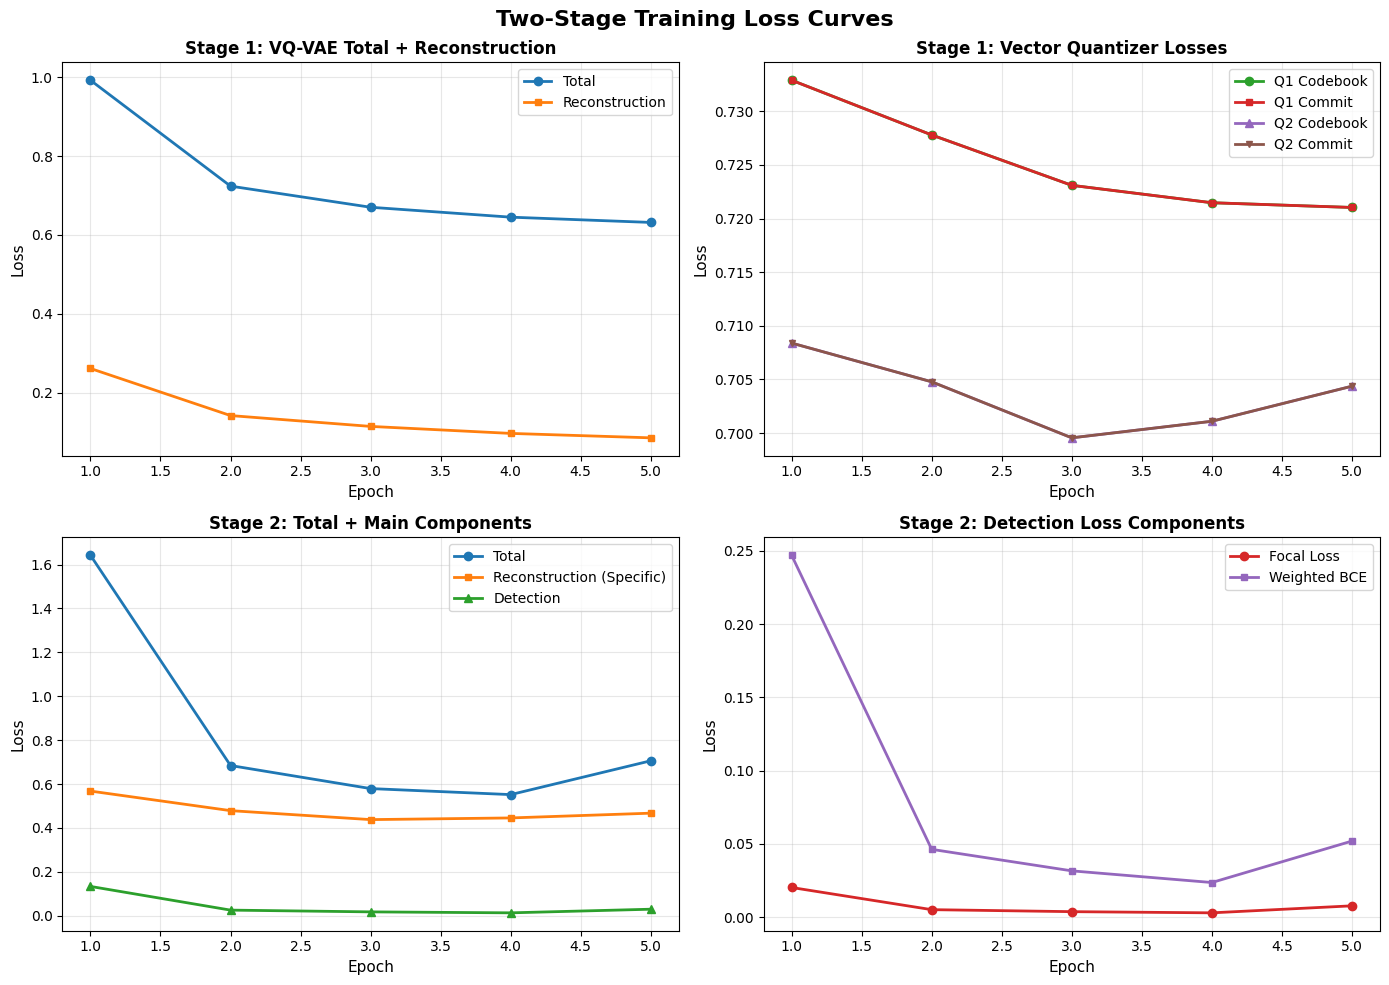

Training curves saved to 'training_loss_curves.png'
Stage 1 training: 5 epochs
Stage 2 training: 5 epochs


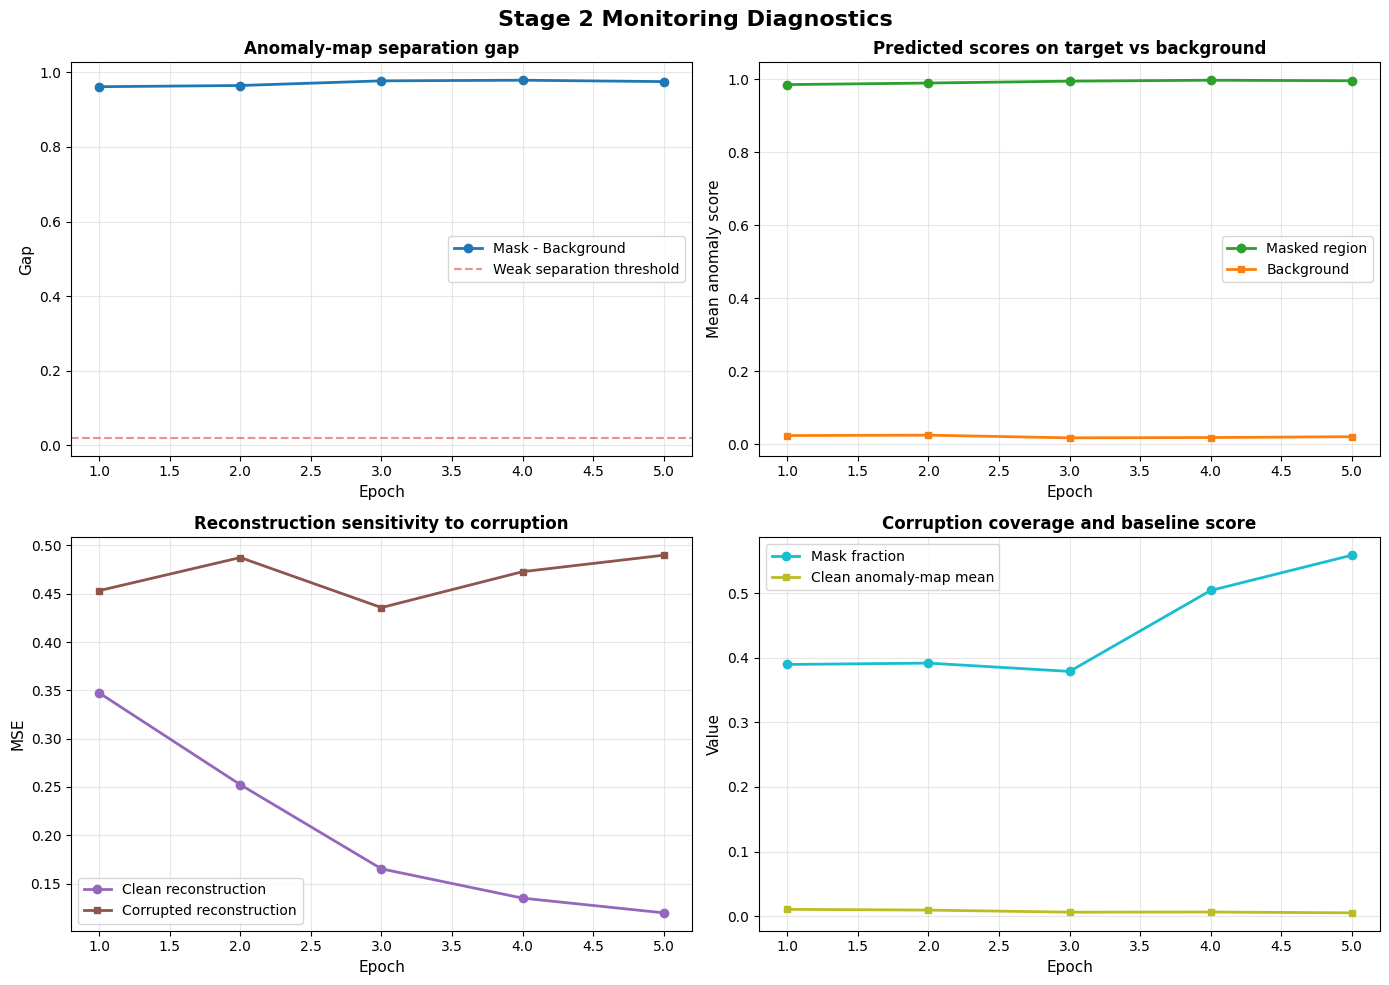

Diagnostics saved to 'stage2_diagnostics_curves.png'
Final monitor gap: 0.9754
Final mask fraction: 0.5586
Final clean/anom reconstruction MSE: 0.1197 / 0.4899


In [69]:
# Plot training loss curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Two-Stage Training Loss Curves', fontsize=16, fontweight='bold')

# Stage 1 losses
epochs_s1 = list(range(1, len(stage1_loss_history["total"]) + 1))

# Stage 1: Total + Reconstruction
axes[0, 0].plot(epochs_s1, stage1_loss_history["total"], 'o-', linewidth=2, markersize=6, label='Total', color='#1f77b4')
axes[0, 0].plot(epochs_s1, stage1_loss_history["rec"], 's-', linewidth=2, markersize=5, label='Reconstruction', color='#ff7f0e')
axes[0, 0].set_xlabel('Epoch', fontsize=11)
axes[0, 0].set_ylabel('Loss', fontsize=11)
axes[0, 0].set_title('Stage 1: VQ-VAE Total + Reconstruction', fontsize=12, fontweight='bold')
axes[0, 0].legend(loc='best')
axes[0, 0].grid(True, alpha=0.3)

# Stage 1: Codebook losses
axes[0, 1].plot(epochs_s1, stage1_loss_history["q1_cb"], 'o-', linewidth=2, markersize=6, label='Q1 Codebook', color='#2ca02c')
axes[0, 1].plot(epochs_s1, stage1_loss_history["q1_cm"], 's-', linewidth=2, markersize=5, label='Q1 Commit', color='#d62728')
axes[0, 1].plot(epochs_s1, stage1_loss_history["q2_cb"], '^-', linewidth=2, markersize=6, label='Q2 Codebook', color='#9467bd')
axes[0, 1].plot(epochs_s1, stage1_loss_history["q2_cm"], 'v-', linewidth=2, markersize=5, label='Q2 Commit', color='#8c564b')
axes[0, 1].set_xlabel('Epoch', fontsize=11)
axes[0, 1].set_ylabel('Loss', fontsize=11)
axes[0, 1].set_title('Stage 1: Vector Quantizer Losses', fontsize=12, fontweight='bold')
axes[0, 1].legend(loc='best')
axes[0, 1].grid(True, alpha=0.3)

# Stage 2 losses
epochs_s2 = list(range(1, len(stage2_loss_history["total"]) + 1))

# Stage 2: Total + Reconstruction + Detection
axes[1, 0].plot(epochs_s2, stage2_loss_history["total"], 'o-', linewidth=2, markersize=6, label='Total', color='#1f77b4')
axes[1, 0].plot(epochs_s2, stage2_loss_history["rec_specific"], 's-', linewidth=2, markersize=5, label='Reconstruction (Specific)', color='#ff7f0e')
axes[1, 0].plot(epochs_s2, stage2_loss_history["det"], '^-', linewidth=2, markersize=6, label='Detection', color='#2ca02c')
axes[1, 0].set_xlabel('Epoch', fontsize=11)
axes[1, 0].set_ylabel('Loss', fontsize=11)
axes[1, 0].set_title('Stage 2: Total + Main Components', fontsize=12, fontweight='bold')
axes[1, 0].legend(loc='best')
axes[1, 0].grid(True, alpha=0.3)

# Stage 2: Detection sub-losses
axes[1, 1].plot(epochs_s2, stage2_loss_history["det_focal"], 'o-', linewidth=2, markersize=6, label='Focal Loss', color='#d62728')
axes[1, 1].plot(epochs_s2, stage2_loss_history["det_bce"], 's-', linewidth=2, markersize=5, label='Weighted BCE', color='#9467bd')
axes[1, 1].set_xlabel('Epoch', fontsize=11)
axes[1, 1].set_ylabel('Loss', fontsize=11)
axes[1, 1].set_title('Stage 2: Detection Loss Components', fontsize=12, fontweight='bold')
axes[1, 1].legend(loc='best')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Training curves saved to 'training_loss_curves.png'")
print(f"Stage 1 training: {len(epochs_s1)} epochs")
print(f"Stage 2 training: {len(epochs_s2)} epochs")

if 'stage2_diagnostics_history' in globals() and len(stage2_diagnostics_history['map_gap']) > 0:
    fig2, axes2 = plt.subplots(2, 2, figsize=(14, 10))
    fig2.suptitle('Stage 2 Monitoring Diagnostics', fontsize=16, fontweight='bold')

    epochs_diag = list(range(1, len(stage2_diagnostics_history['map_gap']) + 1))

    axes2[0, 0].plot(epochs_diag, stage2_diagnostics_history['map_gap'], 'o-', linewidth=2, markersize=6, color='#1f77b4', label='Mask - Background')
    axes2[0, 0].axhline(0.02, color='#d62728', linestyle='--', alpha=0.5, label='Weak separation threshold')
    axes2[0, 0].set_xlabel('Epoch', fontsize=11)
    axes2[0, 0].set_ylabel('Gap', fontsize=11)
    axes2[0, 0].set_title('Anomaly-map separation gap', fontsize=12, fontweight='bold')
    axes2[0, 0].legend(loc='best')
    axes2[0, 0].grid(True, alpha=0.3)

    axes2[0, 1].plot(epochs_diag, stage2_diagnostics_history['map_mask_mean'], 'o-', linewidth=2, markersize=6, color='#2ca02c', label='Masked region')
    axes2[0, 1].plot(epochs_diag, stage2_diagnostics_history['map_bg_mean'], 's-', linewidth=2, markersize=5, color='#ff7f0e', label='Background')
    axes2[0, 1].set_xlabel('Epoch', fontsize=11)
    axes2[0, 1].set_ylabel('Mean anomaly score', fontsize=11)
    axes2[0, 1].set_title('Predicted scores on target vs background', fontsize=12, fontweight='bold')
    axes2[0, 1].legend(loc='best')
    axes2[0, 1].grid(True, alpha=0.3)

    axes2[1, 0].plot(epochs_diag, stage2_diagnostics_history['clean_rec_mse'], 'o-', linewidth=2, markersize=6, color='#9467bd', label='Clean reconstruction')
    axes2[1, 0].plot(epochs_diag, stage2_diagnostics_history['anom_rec_mse'], 's-', linewidth=2, markersize=5, color='#8c564b', label='Corrupted reconstruction')
    axes2[1, 0].set_xlabel('Epoch', fontsize=11)
    axes2[1, 0].set_ylabel('MSE', fontsize=11)
    axes2[1, 0].set_title('Reconstruction sensitivity to corruption', fontsize=12, fontweight='bold')
    axes2[1, 0].legend(loc='best')
    axes2[1, 0].grid(True, alpha=0.3)

    axes2[1, 1].plot(epochs_diag, stage2_diagnostics_history['mask_frac'], 'o-', linewidth=2, markersize=6, color='#17becf', label='Mask fraction')
    axes2[1, 1].plot(epochs_diag, stage2_diagnostics_history['clean_map_mean'], 's-', linewidth=2, markersize=5, color='#bcbd22', label='Clean anomaly-map mean')
    axes2[1, 1].set_xlabel('Epoch', fontsize=11)
    axes2[1, 1].set_ylabel('Value', fontsize=11)
    axes2[1, 1].set_title('Corruption coverage and baseline score', fontsize=12, fontweight='bold')
    axes2[1, 1].legend(loc='best')
    axes2[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('stage2_diagnostics_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

    final_gap = stage2_diagnostics_history['map_gap'][-1]
    final_mask_frac = stage2_diagnostics_history['mask_frac'][-1]
    final_clean_rec = stage2_diagnostics_history['clean_rec_mse'][-1]
    final_anom_rec = stage2_diagnostics_history['anom_rec_mse'][-1]
    print(f"Diagnostics saved to 'stage2_diagnostics_curves.png'")
    print(f"Final monitor gap: {final_gap:.4f}")
    print(f"Final mask fraction: {final_mask_frac:.4f}")
    print(f"Final clean/anom reconstruction MSE: {final_clean_rec:.4f} / {final_anom_rec:.4f}")
    if final_gap < 0.02:
        print("[Stage2][Warn] Final detector separation is still weak.")
    if final_anom_rec <= final_clean_rec:
        print("[Stage2][Warn] Corrupted inputs are not producing a harder reconstruction problem.")

Codebook usage diagnostics:
- Q1 usage:      0.2090
- Q1 perplexity: 83.17
- Q2 usage:      0.7227
- Q2 perplexity: 410.62
Calibration diagnostics:
- calibration files:        175
- final detector gap:       0.9754
- audit rec/map weights:    0.85 / 0.15
- calibrated threshold:     0.2751
- calibration quantile:     0.99


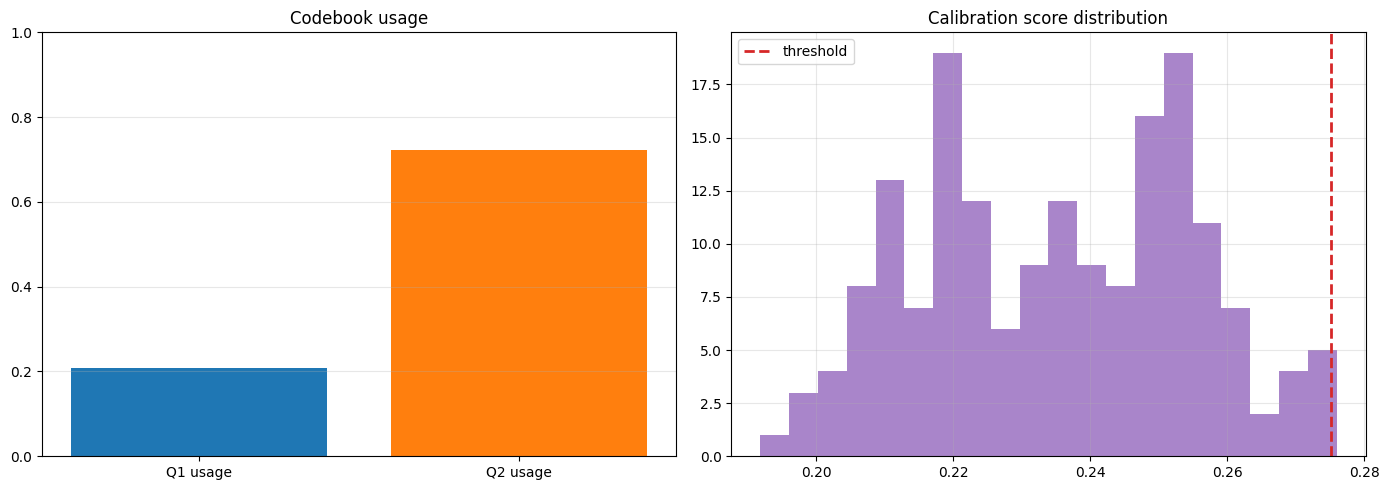

In [70]:
# Calibration and codebook diagnostics.
if "paper_model" not in globals():
    raise RuntimeError("Run the training cell first so paper_model exists.")
if "monitor_x_v2" not in globals():
    raise RuntimeError("Run the training cell first so monitor_x_v2 exists.")

paper_model.eval()
discrete_ae.eval()

# Inspect quantizer usage on the same monitor batch used during training diagnostics.
with torch.no_grad():
    stage1_monitor = discrete_ae(monitor_x_v2)
    q1_usage, q1_ppl = quantizer_usage_stats(stage1_monitor["q1_idx"], q_cfg["q1_embeddings"])
    q2_usage, q2_ppl = quantizer_usage_stats(stage1_monitor["q2_idx"], q_cfg["q2_embeddings"])

print("Codebook usage diagnostics:")
print(f"- Q1 usage:      {q1_usage:.4f}")
print(f"- Q1 perplexity: {q1_ppl:.2f}")
print(f"- Q2 usage:      {q2_usage:.4f}")
print(f"- Q2 perplexity: {q2_ppl:.2f}")
if q1_usage < 0.10 or q2_usage < 0.10:
    print("[Diag][Warn] Codebook collapse is still likely.")

# Calibration threshold from normal training files.
calibration_files = collect_multi_machine_split_files_limited(
    DATA_ROOT,
    STAGE2_MACHINE_TYPES,
    "train",
    max_per_machine=CALIBRATION_FILES_PER_MACHINE,
    seed=SUBSET_SEED + 101,
 )

if len(calibration_files) == 0:
    raise RuntimeError("Calibration file collection returned no files.")

if "stage2_diagnostics_history" in globals() and len(stage2_diagnostics_history["map_gap"]) > 0:
    final_gap = stage2_diagnostics_history["map_gap"][-1]
else:
    final_gap = 0.0

audit_map_weight = AUDIT_MAP_WEIGHT if final_gap >= MAP_GAP_BLEND_THRESHOLD else 0.0
audit_rec_weight = 1.0 - audit_map_weight

def calibration_file_score(file_path):
    waveform = load_waveform(file_path)
    x = waveform_to_model_input(waveform, mel_transform_v2, f_cfg).unsqueeze(0).to(device)
    with torch.no_grad():
        out = paper_model(x, apply_anomaly=False)
    rec_score = float(torch.abs(x - out["x_specific"]).mean().item())
    map_score = float(anomaly_map_to_file_score(out["anomaly_map"], topk_ratio=TOPK_RATIO).mean().item())
    return audit_rec_weight * rec_score + audit_map_weight * map_score

calibration_scores = np.asarray([calibration_file_score(path) for path in calibration_files], dtype=np.float32)
audit_threshold = float(np.quantile(calibration_scores, CALIBRATION_QUANTILE))

print("Calibration diagnostics:")
print(f"- calibration files:        {len(calibration_files)}")
print(f"- final detector gap:       {final_gap:.4f}")
print(f"- audit rec/map weights:    {audit_rec_weight:.2f} / {audit_map_weight:.2f}")
print(f"- calibrated threshold:     {audit_threshold:.4f}")
print(f"- calibration quantile:     {CALIBRATION_QUANTILE}")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].bar(["Q1 usage", "Q2 usage"], [q1_usage, q2_usage], color=["#1f77b4", "#ff7f0e"])
ax[0].set_ylim(0, 1)
ax[0].set_title("Codebook usage")
ax[0].grid(True, axis="y", alpha=0.3)

ax[1].hist(calibration_scores, bins=20, color="#9467bd", alpha=0.8)
ax[1].axvline(audit_threshold, color="#d62728", linestyle="--", linewidth=2, label="threshold")
ax[1].set_title("Calibration score distribution")
ax[1].legend(loc="best")
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

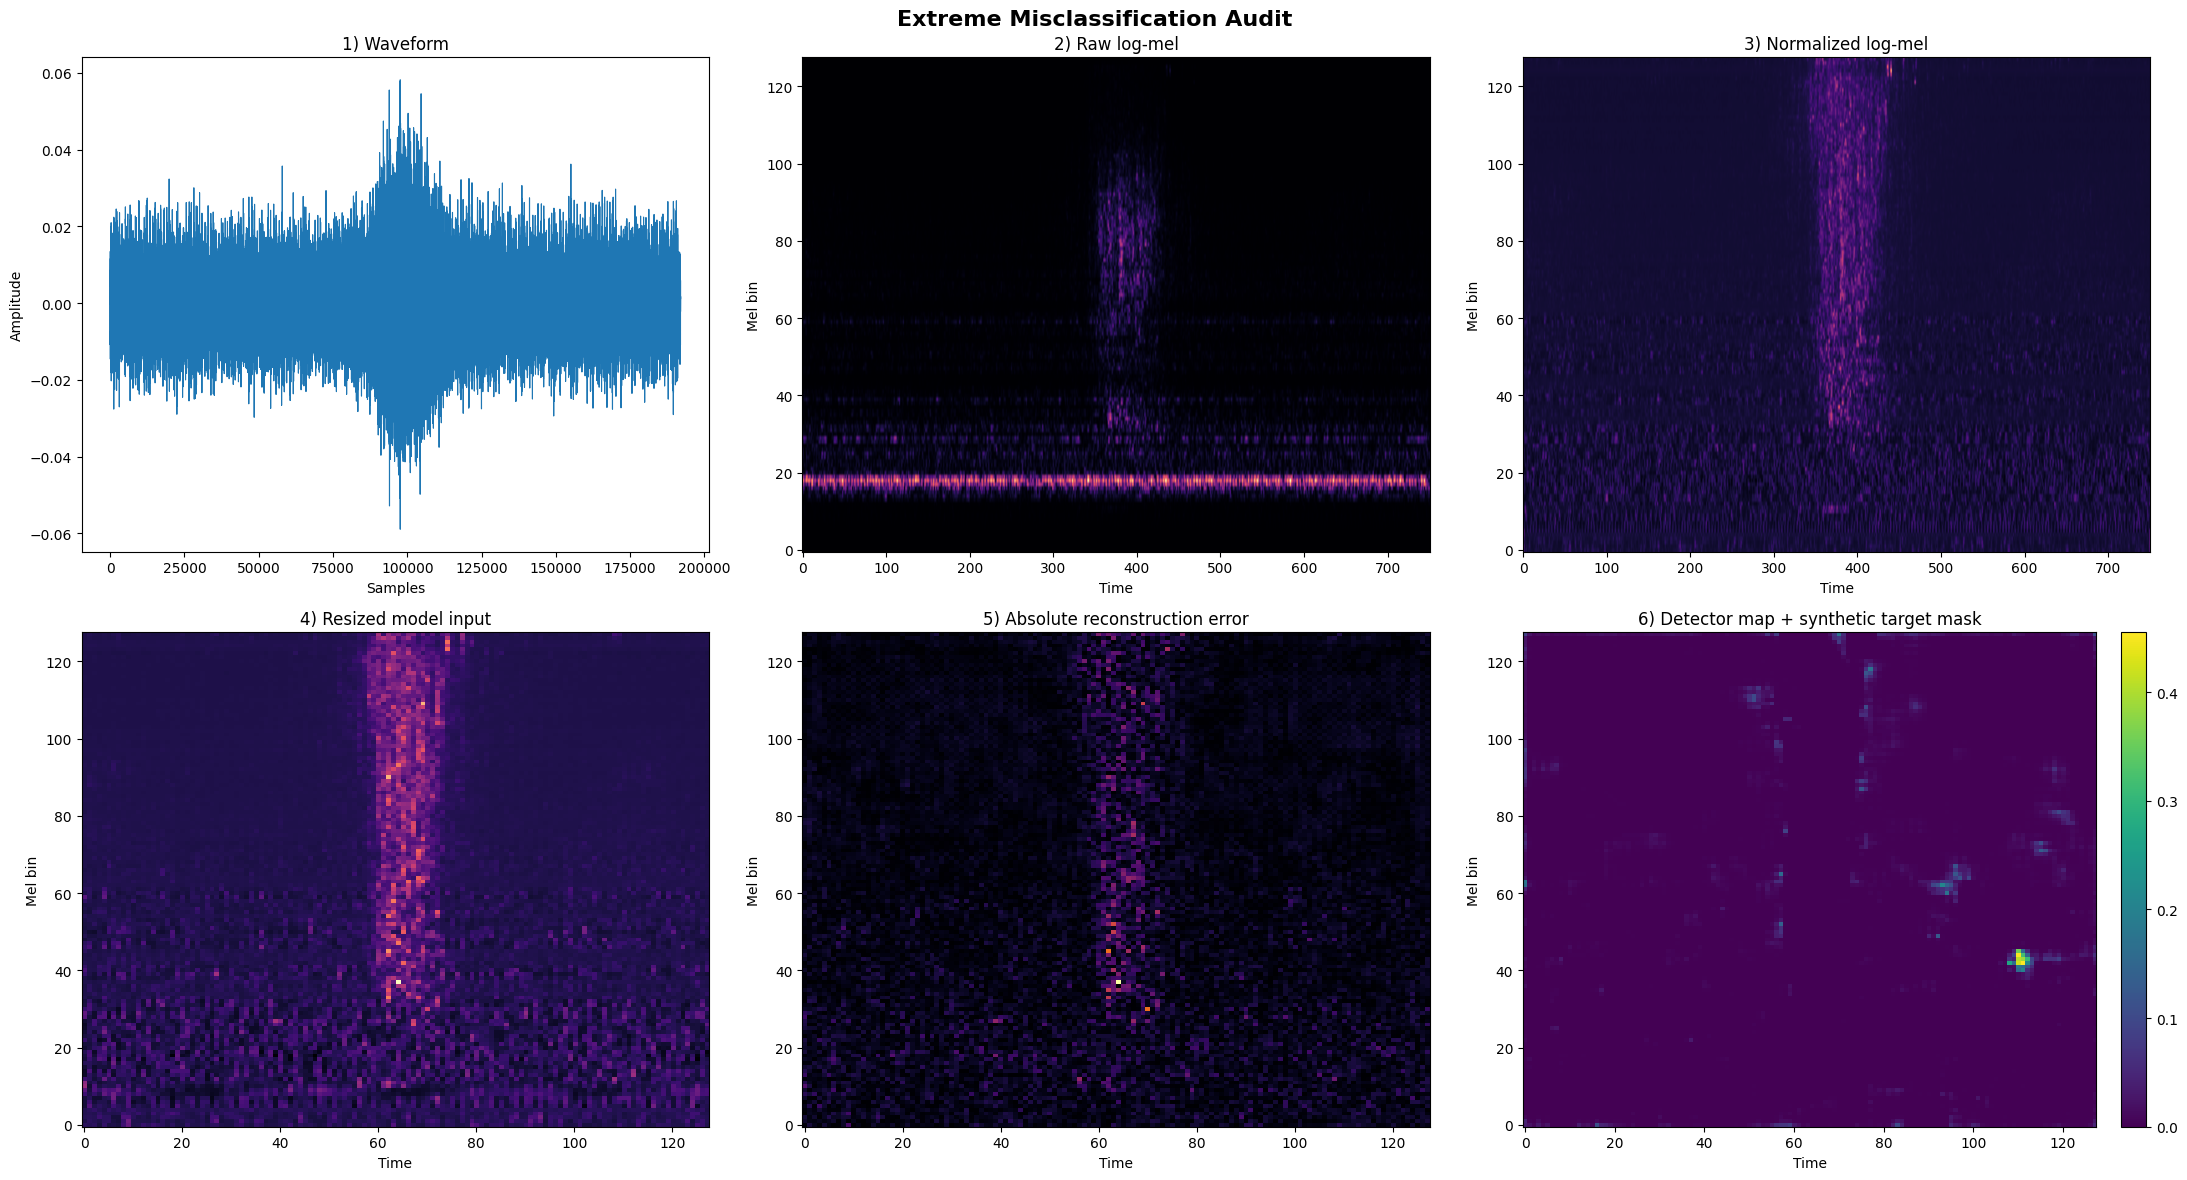

Chosen sample: C:\Users\20223669\OneDrive - TU Eindhoven\Desktop\Soroma Internship\15097779\dev_ToyTrain\ToyTrain\test\section_00_source_test_anomaly_0009_noAttribute.wav
True label: anomaly
Predicted label: normal
Mistake type: false negative
Threshold source: calibrated from train-normal scores
Threshold used: 0.2751
Combined file score: 0.2001
Pseudo-probability of anomaly: 0.0000
Mistake confidence: 1.0000
Reconstruction score: 0.2294
Map score: 0.0339
Audit score weights: 0.85 / 0.15
Processing path:
  1. waveform -> log-mel spectrogram
  2. spectrogram normalization
  3. resize to 128x128
  4. frozen discrete AE produces clean reconstruction
  5. reconstruction error is converted to file score
  6. detector map is reduced to a top-k map score
  7. combined score is mapped to a pseudo-probability
  8. the pseudo-probability is thresholded into a file-level prediction


In [71]:
# Extreme-mistake audit: show a sample the model is wildly wrong about and trace its processing.
if "paper_model" not in globals():
    raise RuntimeError("Run the training and evaluation cells first so paper_model exists.")
if "audit_threshold" not in globals():
    print("[Audit][Warn] No calibrated threshold found; using the audit batch median as fallback.")

# Collect a scored subset from the available test set.
audit_files = collect_multi_machine_split_files_limited(
    DATA_ROOT,
    STAGE2_MACHINE_TYPES,
    "test",
    max_per_machine=max(5, SUBSET_TEST_PER_MACHINE if SUBSET_TEST_PER_MACHINE > 0 else 5),
    seed=SUBSET_SEED + 17,
 )

if len(audit_files) == 0:
    raise RuntimeError("No test files found for audit. Check DATA_ROOT and dataset layout.")

def file_level_anomaly_score(model_obj, file_path, topk_ratio=0.05):
    waveform = load_waveform(file_path)
    spec_raw = torch.log1p(mel_transform_v2(waveform)).unsqueeze(0)
    spec_norm = normalize_spec(spec_raw.clone(), f_cfg["norm"])
    spec_model = F.interpolate(
        spec_norm.unsqueeze(0),
        size=(SPEC_SIZE, SPEC_SIZE),
        mode="bilinear",
        align_corners=False,
    ).squeeze(0)
    x = spec_model.unsqueeze(0).to(device)

    with torch.no_grad():
        out = model_obj(x, apply_anomaly=False)
        rec_err = torch.abs(x - out["x_specific"])
        anomaly_map = out["anomaly_map"]

    rec_score = float(rec_err.mean().item())
    map_score = float(anomaly_map_to_file_score(anomaly_map, topk_ratio=topk_ratio).mean().item())
    rec_weight = globals().get("audit_rec_weight", REC_SCORE_WEIGHT)
    map_weight = globals().get("audit_map_weight", MAP_SCORE_WEIGHT)
    combined = rec_weight * rec_score + map_weight * map_score
    return {
        "waveform": waveform,
        "spec_raw": spec_raw.squeeze(0),
        "spec_norm": spec_norm.squeeze(0),
        "spec_model": spec_model,
        "x": x,
        "out": out,
        "rec_score": rec_score,
        "map_score": map_score,
        "combined": combined,
    }

audit_rows = []
for path in audit_files:
    label = infer_label_from_filename(path)
    if label is None:
        continue
    scores = file_level_anomaly_score(paper_model, path, topk_ratio=TOPK_RATIO)
    audit_rows.append({
        "path": path,
        "label": label,
        "score": scores["combined"],
        "rec_score": scores["rec_score"],
        "map_score": scores["map_score"],
        **scores,
    })

if len(audit_rows) == 0:
    raise RuntimeError("Could not infer labels from any sampled test file names.")

scores_np = np.asarray([row["score"] for row in audit_rows], dtype=np.float32)
labels_np = np.asarray([row["label"] for row in audit_rows], dtype=np.int32)
score_sigma = float(scores_np.std() + 1e-6)

if "audit_threshold" in globals():
    threshold = float(audit_threshold)
    threshold_source = "calibrated from train-normal scores"
else:
    threshold = float(np.median(scores_np))
    threshold_source = "median of audited batch"

def score_to_prob(score):
    z = (score - threshold) / score_sigma
    return float(1.0 / (1.0 + np.exp(-5.0 * z)))

for row in audit_rows:
    row["prob_anomaly"] = score_to_prob(row["score"])
    row["pred"] = int(row["prob_anomaly"] >= 0.5)
    row["confidence"] = float(abs(row["prob_anomaly"] - 0.5) * 2.0)

false_pos = [row for row in audit_rows if row["label"] == 0 and row["pred"] == 1 and row["prob_anomaly"] >= 0.95]
false_neg = [row for row in audit_rows if row["label"] == 1 and row["pred"] == 0 and row["prob_anomaly"] <= 0.05]

candidate_pool = false_pos + false_neg
if len(candidate_pool) == 0:
    candidate_pool = audit_rows

chosen = max(candidate_pool, key=lambda row: abs(row["prob_anomaly"] - 0.5))
chosen_true = int(chosen["label"])
chosen_pred = int(chosen["pred"])
chosen_prob = float(chosen["prob_anomaly"])
mistake_kind = "false positive" if chosen_true == 0 and chosen_pred == 1 else "false negative" if chosen_true == 1 and chosen_pred == 0 else "not a mistake"

waveform = chosen["waveform"].detach().cpu().numpy()
spec_raw_np = chosen["spec_raw"].detach().cpu().numpy()
spec_norm_np = chosen["spec_norm"].detach().cpu().numpy()
spec_model_np = chosen["spec_model"].detach().cpu().numpy()
x_np = chosen["x"].squeeze().detach().cpu().numpy()
out_np = chosen["out"]["x_specific"].squeeze().detach().cpu().numpy()
anom_map_np = chosen["out"]["anomaly_map"].squeeze().detach().cpu().numpy()
rec_err_np = np.abs(x_np - out_np)

with torch.no_grad():
    mask_for_demo = chosen["out"]["mask"].float()
    mask_for_demo = F.interpolate(mask_for_demo, size=anom_map_np.shape[-2:], mode="nearest").squeeze().cpu().numpy()

fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle("Extreme Misclassification Audit", fontsize=16, fontweight="bold")

axes[0, 0].plot(waveform, linewidth=0.8, color="#1f77b4")
axes[0, 0].set_title("1) Waveform")
axes[0, 0].set_xlabel("Samples")
axes[0, 0].set_ylabel("Amplitude")

axes[0, 1].imshow(spec_raw_np, origin="lower", aspect="auto", cmap="magma")
axes[0, 1].set_title("2) Raw log-mel")
axes[0, 1].set_xlabel("Time")
axes[0, 1].set_ylabel("Mel bin")

axes[0, 2].imshow(spec_norm_np, origin="lower", aspect="auto", cmap="magma")
axes[0, 2].set_title("3) Normalized log-mel")
axes[0, 2].set_xlabel("Time")
axes[0, 2].set_ylabel("Mel bin")

axes[1, 0].imshow(spec_model_np.squeeze(), origin="lower", aspect="auto", cmap="magma")
axes[1, 0].set_title("4) Resized model input")
axes[1, 0].set_xlabel("Time")
axes[1, 0].set_ylabel("Mel bin")

axes[1, 1].imshow(rec_err_np, origin="lower", aspect="auto", cmap="inferno")
axes[1, 1].set_title("5) Absolute reconstruction error")
axes[1, 1].set_xlabel("Time")
axes[1, 1].set_ylabel("Mel bin")

im = axes[1, 2].imshow(anom_map_np, origin="lower", aspect="auto", cmap="viridis")
axes[1, 2].contour(mask_for_demo, levels=[0.5], colors=["cyan"], linewidths=1.0)
axes[1, 2].set_title("6) Detector map + synthetic target mask")
axes[1, 2].set_xlabel("Time")
axes[1, 2].set_ylabel("Mel bin")
fig.colorbar(im, ax=axes[1, 2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print(f"Chosen sample: {chosen['path']}")
print(f"True label: {'anomaly' if chosen_true == 1 else 'normal'}")
print(f"Predicted label: {'anomaly' if chosen_pred == 1 else 'normal'}")
print(f"Mistake type: {mistake_kind}")
print(f"Threshold source: {threshold_source}")
print(f"Threshold used: {threshold:.4f}")
print(f"Combined file score: {chosen['score']:.4f}")
print(f"Pseudo-probability of anomaly: {chosen_prob:.4f}")
print(f"Mistake confidence: {chosen['confidence']:.4f}")
print(f"Reconstruction score: {chosen['rec_score']:.4f}")
print(f"Map score: {chosen['map_score']:.4f}")
print(f"Audit score weights: {globals().get('audit_rec_weight', REC_SCORE_WEIGHT):.2f} / {globals().get('audit_map_weight', MAP_SCORE_WEIGHT):.2f}")
print("Processing path:")
print("  1. waveform -> log-mel spectrogram")
print("  2. spectrogram normalization")
print(f"  3. resize to {SPEC_SIZE}x{SPEC_SIZE}")
print("  4. frozen discrete AE produces clean reconstruction")
print("  5. reconstruction error is converted to file score")
print("  6. detector map is reduced to a top-k map score")
print("  7. combined score is mapped to a pseudo-probability")
print("  8. the pseudo-probability is thresholded into a file-level prediction")
if mistake_kind == "not a mistake":
    print("No extreme mistake found in this audit batch, so the cell showed the farthest borderline sample instead.")

In [72]:
from pathlib import Path

checkpoint_dir = Path("checkpoints")
checkpoint_dir.mkdir(parents=True, exist_ok=True)
previous_model_path = checkpoint_dir / "paper_model_before_stage1_tuning.pt"

checkpoint_payload = {
    "paper_model_state": paper_model.state_dict(),
    "discrete_ae_state": discrete_ae.state_dict(),
    "threshold": threshold,
    "threshold_source": threshold_source,
    "stage1_loss_history": stage1_loss_history,
    "stage2_loss_history": stage2_loss_history,
    "stage2_diagnostics_history": stage2_diagnostics_history,
    "q_cfg": q_cfg,
    "f_cfg": f_cfg,
    "c_cfg": c_cfg,
    "d_cfg": d_cfg,
}

torch.save(checkpoint_payload, previous_model_path)
print(f"Saved previous model checkpoint to: {previous_model_path}")
print(f"Saved keys: {sorted(checkpoint_payload.keys())}")

Saved previous model checkpoint to: checkpoints\paper_model_before_stage1_tuning.pt
Saved keys: ['c_cfg', 'd_cfg', 'discrete_ae_state', 'f_cfg', 'paper_model_state', 'q_cfg', 'stage1_loss_history', 'stage2_diagnostics_history', 'stage2_loss_history', 'threshold', 'threshold_source']


## Archived / Optional Code (Doc Cell)

To keep the notebook concise, optional experiments were moved out of the active flow.

Removed from active execution:
- Early mock-model smoke test and single-machine demo visualization
- Subset-based combined/map/rec scoring and histogram plotting
- Machine-wise post-hoc calibration cell
- Machine-specific Stage 2 training (option 2) and compact summary
- Detector sanity, detector-rescue, and hard-negative rescue experiments
- Subset-based unsupervised kNN scoring prototype

Current active flow is now:
1. Imports
2. Experiment config
3. Data/audio utility functions
4. Model + losses
5. Two-stage training
6. Full-dataset unsupervised evaluation

If you want, I can also place the removed code into a separate notebook file (for example: `zvratnik_AE_archive.ipynb`) so nothing is lost while this notebook stays clean.